# Proiect 3 - Detection, Segmentation and Multi-Head Architectures

## Descriere generala

Acest proiect are ca obiectiv dezvoltarea si evaluarea unui model de computer vision pentru un task de **instance segmentation**. Mai exact, dorim sa antrenam un model capabil sa identifice obiecte de tip deseu din imagini reale, sa le localizeze prin **bounding boxes** si sa produca pentru fiecare obiect o **masca de segmentare**.

Pentru aceasta problema am ales modelul **Mask R-CNN cu backbone ResNet-50 si FPN**, deoarece acesta este potrivit pentru arhitecturi multi-head: modelul poate prezice simultan clasele obiectelor, coordonatele bounding box-urilor si mastile de segmentare.

## Dataset ales

Dataset-ul utilizat este **TACO Trash Segmentation** (https://universe.roboflow.com/corey-hughes/taco-trash-segmentation), un dataset real de **instance segmentation**, care contine imagini cu obiecte de tip deseu in contexte variate. Dataset-ul este impartit in:
- **Train:** 1054 imagini
- **Validation:** 300 imagini
- **Test:** 150 imagini

Acest dataset a fost ales deoarece:
- este un dataset real, potrivit pentru cerintele proiectului;
- contine adnotari de tip segmentare, necesare pentru Mask R-CNN;
- are o dimensiune suficient de mare pentru antrenare, dar ramane fezabil pe Google Colab cu GPU T4;
- problema are relevanta practica in aplicatii precum reciclare, monitorizare urbana si analiza de mediu.

## Obiectivele proiectului

In cadrul acestui notebook vom parcurge urmatorii pasi:
1. configurarea mediului de lucru si asigurarea reproductibilitatii;
2. analiza si vizualizarea dataset-ului;
3. preprocesarea si verificarea integritatii datelor;
4. definirea si configurarea modelului;
5. fine-tuning-ul modelului pre-antrenat;
6. evaluarea performantelor folosind metrici specifice pentru detection si segmentation;
7. analiza calitativa a rezultatelor prin afisarea predictiilor pe imagini din setul de test.

## Rezultatul urmarit

La finalul proiectului ne propunem sa obtinem un model capabil sa:
- detecteze obiectele de interes din imagine;
- prezica clasa fiecarui obiect;
- genereze o masca de segmentare pentru fiecare instanta detectata;
- ofere rezultate suficient de bune pentru a demonstra aplicabilitatea unei arhitecturi multi-head intr-un scenariu real.

# 0. Dependinte si importuri

Toate pachetele si importurile sunt grupate aici. Restul notebook-ului foloseste aceste importuri, fara duplicate prin mijlocul proiectului.

Pentru demo, notebook-ul incearca sa refoloseasca fisierele din Google Drive (`outputs/`, `requirements.txt`, checkpoint-uri si CSV-uri). Daca checkpoint-urile nu exista, celulele de training pornesc automat antrenarea.

In [1]:
# Bootstrap dependinte. Ruleaza rapid daca pachetele exista deja in Colab.
import importlib.util
import subprocess
import sys

AUTO_INSTALL_MISSING_PACKAGES = True
REQUIRED_PACKAGES = {
    "pycocotools": "pycocotools",
    "albumentations": "albumentations",
    "cv2": "opencv-python-headless",
    "sklearn": "scikit-learn",
    "roboflow": "roboflow",
}
missing_packages = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing_packages and AUTO_INSTALL_MISSING_PACKAGES:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
elif missing_packages:
    print("Missing packages, but AUTO_INSTALL_MISSING_PACKAGES=False:", missing_packages)
else:
    print("All required packages are available.")

Installing missing packages: ['roboflow']


In [2]:
# Importuri standard library
import hashlib
import importlib
import json
import math
import os
import random
import shutil
import subprocess
import sys
import textwrap
import time
from collections import Counter, defaultdict
from pathlib import Path

# Data science / vizualizare
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import Image as IPyImage
from IPython.display import Markdown, display
from PIL import Image

# Computer vision / augmentari / COCO
import albumentations as A
import cv2
from pycocotools import mask as mask_utils
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# PyTorch / torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights, maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
# Metrici auxiliare
from sklearn.metrics import average_precision_score, precision_recall_fscore_support

try:
    from google.colab import drive, userdata
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    userdata = None
    IN_COLAB = False

try:
    from roboflow import Roboflow
    ROBOFLOW_AVAILABLE = True
except ModuleNotFoundError:
    Roboflow = None
    ROBOFLOW_AVAILABLE = False

print("Imports loaded successfully.")
print("Running in Colab:", IN_COLAB)

Imports loaded successfully.
Running in Colab: True


In [3]:
# Helperi mici pentru tabele, figuri si raportare.
def show_table(df, caption=None, precision=4):
    if df is None or len(df) == 0:
        print("No rows to display.")
        return
    numeric_cols = df.select_dtypes(include=["number"]).columns
    styler = df.style.format({col: f"{{:.{precision}f}}" for col in numeric_cols})
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

def save_figure(path, dpi=150):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)

# 1. Setup & Reproductibilitate

Aceasta sectiune configureaza mediul de lucru pentru proiect.

Obiective:
- verificarea disponibilitatii GPU-ului;
- setarea seed-ului pentru reproductibilitate;
- importarea bibliotecilor principale;
- montarea Google Drive;
- definirea configuratiei globale a proiectului;
- crearea structurii de directoare persistente in `drive/MyDrive/ProiectD3`;
- pregatirea notebook-ului pentru rulare end-to-end.

Pentru reproductibilitate, folosim un seed fix si pastram hiperparametrii principali intr-un dictionar `CONFIG`. Dataset-ul si outputurile sunt salvate in Google Drive, ca sa nu fie pierdute cand se reseteaza runtime-ul Colab.


In [4]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
SEED = 42

def set_seed(seed):
    """
    Seteaza seed-ul pentru reproductibilitate.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Setari pentru comportament mai determinist in PyTorch.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = DEVICE

print("Seed:", SEED)
print("Device:", DEVICE)

Seed: 42
Device: cuda


In [6]:
CONFIG = {
    "project_name": "TACO Trash Instance Segmentation",
    "task": "instance_segmentation",
    "dataset_name": "TACO Trash Segmentation",
    "dataset_format": "COCO Segmentation",

    "seed": SEED,
    "device": str(DEVICE),

    # Training config
    "batch_size": 2,
    "num_workers": 2,
    "num_epochs": 5,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,

    # Model config
    "model_name": "Mask R-CNN ResNet-50 FPN",
    "pretrained": True,
    "score_threshold": 0.5,

    # Dataset config
    "image_size": 512,
    "train_split": "train",
    "valid_split": "valid",
    "test_split": "test",
}

CONFIG

{'project_name': 'TACO Trash Instance Segmentation',
 'task': 'instance_segmentation',
 'dataset_name': 'TACO Trash Segmentation',
 'dataset_format': 'COCO Segmentation',
 'seed': 42,
 'device': 'cuda',
 'batch_size': 2,
 'num_workers': 2,
 'num_epochs': 5,
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'model_name': 'Mask R-CNN ResNet-50 FPN',
 'pretrained': True,
 'score_threshold': 0.5,
 'image_size': 512,
 'train_split': 'train',
 'valid_split': 'valid',
 'test_split': 'test'}

In [7]:
# Montam Google Drive si definim directoarele persistente ale proiectului.
if IN_COLAB and drive is not None:
    drive.mount("/content/drive")
else:
    print("Google Colab nu este disponibil. Folosesc directoarele locale existente.")

PROJECT_ROOT = Path("/content/drive/MyDrive/ProiectD3") if IN_COLAB else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATASET_DIR = DATA_DIR / "TACO-Trash-Segmentation-1"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = OUTPUTS_DIR / "models"
LOGS_DIR = OUTPUTS_DIR / "logs"
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

for directory in [PROJECT_ROOT, DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR, LOGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)

CONFIG.update({
    "project_root": str(PROJECT_ROOT),
    "data_dir": str(DATA_DIR),
    "dataset_dir": str(DATASET_DIR),
    "outputs_dir": str(OUTPUTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "models_dir": str(MODELS_DIR),
    "logs_dir": str(LOGS_DIR),
})

print("Project directories:")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("REQUIREMENTS_PATH:", REQUIREMENTS_PATH)

Mounted at /content/drive
Project directories:
PROJECT_ROOT: /content/drive/MyDrive/ProiectD3
DATA_DIR: /content/drive/MyDrive/ProiectD3/data
DATASET_DIR: /content/drive/MyDrive/ProiectD3/data/TACO-Trash-Segmentation-1
OUTPUTS_DIR: /content/drive/MyDrive/ProiectD3/outputs
FIGURES_DIR: /content/drive/MyDrive/ProiectD3/outputs/figures
MODELS_DIR: /content/drive/MyDrive/ProiectD3/outputs/models
LOGS_DIR: /content/drive/MyDrive/ProiectD3/outputs/logs
REQUIREMENTS_PATH: /content/drive/MyDrive/ProiectD3/requirements.txt


In [8]:
EXPECTED_DATASET_DIR = DATASET_DIR
TEMP_COLAB_DATASET_DIR = Path("/content/TACO-Trash-Segmentation-1")

if EXPECTED_DATASET_DIR.exists():
    DATASET_DIR = EXPECTED_DATASET_DIR
    print("Dataset already exists in Drive. Download skipped.")
    print("Dataset directory:", DATASET_DIR)
elif TEMP_COLAB_DATASET_DIR.exists():
    print("Dataset found in temporary Colab storage. Copying it to Drive...")
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(TEMP_COLAB_DATASET_DIR, DATASET_DIR)
    print("Dataset copied to Drive.")
else:
    if not (IN_COLAB and userdata is not None and ROBOFLOW_AVAILABLE):
        raise RuntimeError("Dataset not found locally. In Colab, set ROBOFLOW_API_KEY in Secrets; local runs should place the dataset under data/TACO-Trash-Segmentation-1.")
    print("Dataset not found in Drive. Downloading from Roboflow...")
    ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
    if ROBOFLOW_API_KEY is None:
        raise ValueError("ROBOFLOW_API_KEY nu este setata in Colab Secrets.")
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("breban-vasile").project("taco-trash-segmentation-lujq0")
    try:
        dataset = project.version(1).download("coco-segmentation", location=str(DATASET_DIR))
        DATASET_DIR = Path(dataset.location)
    except TypeError:
        dataset = project.version(1).download("coco-segmentation")
        downloaded_dataset_dir = Path(dataset.location)
        DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
        if DATASET_DIR.exists():
            shutil.rmtree(DATASET_DIR)
        shutil.move(str(downloaded_dataset_dir), str(DATASET_DIR))

CONFIG["dataset_dir"] = str(DATASET_DIR)
CONFIG["dataset_cached_in_drive"] = str(DATASET_DIR).startswith(str(PROJECT_ROOT))
print("Final DATASET_DIR:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())
print("Contents:", os.listdir(DATASET_DIR))

Dataset already exists in Drive. Download skipped.
Dataset directory: /content/drive/MyDrive/ProiectD3/data/TACO-Trash-Segmentation-1
Final DATASET_DIR: /content/drive/MyDrive/ProiectD3/data/TACO-Trash-Segmentation-1
Exists: True
Contents: ['test', 'train', 'valid', 'README.roboflow.txt', 'README.dataset.txt']


In [9]:
for split in ["train", "valid", "test"]:
    split_dir = DATASET_DIR / split
    annotation_file = split_dir / "_annotations.coco.json"

    print(f"\nSplit: {split}")
    print("Split directory exists:", split_dir.exists())
    print("Annotation file exists:", annotation_file.exists())

    if split_dir.exists():
        image_files = [
            file for file in split_dir.iterdir()
            if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]
        print("Number of image files:", len(image_files))


Split: train
Split directory exists: True
Annotation file exists: True
Number of image files: 1054

Split: valid
Split directory exists: True
Annotation file exists: True
Number of image files: 300

Split: test
Split directory exists: True
Annotation file exists: True
Number of image files: 150


In [10]:
config_path = OUTPUTS_DIR / "config.json"

with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Config saved to: {config_path}")

Config saved to: /content/drive/MyDrive/ProiectD3/outputs/config.json


In [11]:
!pip freeze > "{REQUIREMENTS_PATH}"
print(f"requirements.txt generated at: {REQUIREMENTS_PATH}")


requirements.txt generated at: /content/drive/MyDrive/ProiectD3/requirements.txt


In [12]:
!head -20 "{REQUIREMENTS_PATH}"


absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21


## Observatii

Notebook-ul ruleaza pe Google Colab folosind GPU Tesla T4. Pentru reproductibilitate, am setat seed-ul global la valoarea 42 si am centralizat hiperparametrii in dictionarul `CONFIG`.

Google Drive este montat la inceputul notebook-ului, iar proiectul este salvat persistent in:

`/content/drive/MyDrive/ProiectD3`

In acest folder se pastreaza:
- dataset-ul descarcat din Roboflow, in `data/`;
- fisierele de configurare si `requirements.txt`;
- figurile, modelele, logurile si adnotarile curatate, in `outputs/`.

Astfel, la o rulare noua in Colab, dataset-ul nu mai trebuie descarcat din nou daca exista deja in Drive.


# 2. Alegerea si Analiza Dataset-ului

Dataset-ul folosit este **TACO Trash Segmentation**, un dataset real cu imagini naturale si adnotari in format **COCO Segmentation**. Sectiunea pastreaza doar analiza ceruta in barem:
- justificarea alegerii dataset-ului;
- definirea task-ului de instance segmentation;
- exemple vizuale adnotate, minimum 5 imagini;
- fezabilitate: dimensiune dataset, compute disponibil, rezolutie, labeluri, distributia claselor si numarul mediu de obiecte per imagine.


## 2.1 Justificarea alegerii dataset-ului

Am ales **TACO Trash Segmentation** deoarece este un dataset real, nu self-made si nu un dataset simplificat precum MNIST sau CIFAR-10. Imaginile contin obiecte de tip deseu in contexte naturale, iar adnotarile includ clasa, bounding box si masca pentru fiecare instanta.

Dataset-ul este potrivit pentru proiect deoarece permite antrenarea unui model de tip **Mask R-CNN** si are relevanta practica pentru reciclare automata, monitorizare urbana si analiza de mediu. Dimensiunea sa este suficienta pentru un proiect de deep learning, dar ramane gestionabila pe Google Colab T4 cu batch size mic si resize controlat.


## 2.2 Definirea task-ului ales

Task-ul ales este **Instance Segmentation**. Pentru fiecare obiect din imagine, modelul trebuie sa prezica:
- clasa obiectului;
- bounding box-ul;
- masca de segmentare;
- scorul de incredere.

Task-ul este mai complex decat object detection, deoarece nu este suficienta localizarea prin bounding box: modelul trebuie sa estimeze si conturul fiecarei instante la nivel de pixel. Aceasta formulare este compatibila cu **Mask R-CNN**, care adauga un mask head peste arhitectura Faster R-CNN.


## 2.3 Incarcarea adnotarilor COCO

Dataset-ul este deja verificat in sectiunea de setup. Aici incarcam direct fisierele COCO pentru split-urile `train`, `valid` si `test`. Formatul COCO contine:
- `images`: nume fisier, latime, inaltime;
- `annotations`: clasa, bounding box, arie si segmentare;
- `categories`: lista claselor.


In [13]:
SPLITS = ["train", "valid", "test"]


def load_coco_annotations(split):
    ann_path = DATASET_DIR / split / "_annotations.coco.json"
    if not ann_path.exists():
        raise FileNotFoundError(f"Annotation file not found: {ann_path}")

    with open(ann_path, "r") as f:
        return json.load(f)


coco_by_split = {split: load_coco_annotations(split) for split in SPLITS}
coco_train = coco_by_split["train"]
coco_valid = coco_by_split["valid"]
coco_test = coco_by_split["test"]

print("Train images:", len(coco_train["images"]))
print("Train annotations:", len(coco_train["annotations"]))
print("Categories:", len(coco_train["categories"]))


Train images: 1054
Train annotations: 3382
Categories: 61


In [14]:
def get_split_statistics(coco_data, split_name):
    """
    Calculeaza statistici generale pentru un split COCO.
    """
    num_images = len(coco_data["images"])
    num_annotations = len(coco_data["annotations"])
    num_categories = len(coco_data["categories"])

    objects_per_image = defaultdict(int)
    for ann in coco_data["annotations"]:
        objects_per_image[ann["image_id"]] += 1

    if len(objects_per_image) > 0:
        avg_objects = sum(objects_per_image.values()) / num_images
        max_objects = max(objects_per_image.values())
    else:
        avg_objects = 0
        max_objects = 0

    return {
        "split": split_name,
        "num_images": num_images,
        "num_annotations": num_annotations,
        "num_categories": num_categories,
        "avg_objects_per_image": avg_objects,
        "max_objects_in_image": max_objects
    }


split_stats = [
    get_split_statistics(coco_train, "train"),
    get_split_statistics(coco_valid, "valid"),
    get_split_statistics(coco_test, "test")
]

split_stats_df = pd.DataFrame(split_stats)
split_stats_df

,split,num_images,num_annotations,num_categories,avg_objects_per_image,max_objects_in_image
0,train,1054,3382,61,3.208729,90
1,valid,300,895,61,2.983333,37
2,test,150,542,61,3.613333,30


## 2.4 Statistici generale ale dataset-ului

Tabelul de mai sus acopera partea de fezabilitate legata de dimensiunea dataset-ului: cate imagini si adnotari exista pe fiecare split si cate obiecte apar in medie intr-o imagine. Aceste valori arata daca problema este gestionabila pe GPU-ul disponibil si cat de aglomerate sunt imaginile.


In [15]:
# Construim mapari intre category_id si numele clasei

categories = coco_train["categories"]

cat_id_to_name = {cat["id"]: cat["name"] for cat in categories}
cat_name_to_id = {cat["name"]: cat["id"] for cat in categories}

print("Number of categories:", len(categories))
print("First 20 categories:")

for cat in categories[:20]:
    print(cat["id"], "-", cat["name"])

Number of categories: 61
First 20 categories:
0 - trash
1 - Aerosol
2 - Aluminium blister pack
3 - Aluminium foil
4 - Battery
5 - Broken glass
6 - Carded blister pack
7 - Cigarette
8 - Clear plastic bottle
9 - Corrugated carton
10 - Crisp packet
11 - Disposable food container
12 - Disposable plastic cup
13 - Drink can
14 - Drink carton
15 - Egg carton
16 - Foam cup
17 - Foam food container
18 - Food Can
19 - Food waste


In [16]:
def compute_class_distribution(coco_data):
    """
    Calculeaza distributia claselor pe baza adnotarilor COCO.
    """
    class_counter = Counter()

    for ann in coco_data["annotations"]:
        category_id = ann["category_id"]
        class_name = cat_id_to_name.get(category_id, f"unknown_{category_id}")
        class_counter[class_name] += 1

    return class_counter


train_class_dist = compute_class_distribution(coco_train)
valid_class_dist = compute_class_distribution(coco_valid)
test_class_dist = compute_class_distribution(coco_test)

class_dist_df = pd.DataFrame({
    "class_name": list(train_class_dist.keys()),
    "train_count": [train_class_dist[class_name] for class_name in train_class_dist.keys()],
    "valid_count": [valid_class_dist.get(class_name, 0) for class_name in train_class_dist.keys()],
    "test_count": [test_class_dist.get(class_name, 0) for class_name in train_class_dist.keys()],
})

class_dist_df["total_count"] = (
    class_dist_df["train_count"] +
    class_dist_df["valid_count"] +
    class_dist_df["test_count"]
)

class_dist_df = class_dist_df.sort_values("total_count", ascending=False).reset_index(drop=True)

class_dist_df.head(20)

,class_name,train_count,valid_count,test_count,total_count
0,Cigarette,430,148,89,667
1,Unlabeled litter,374,93,50,517
2,Plastic film,310,81,60,451
3,Clear plastic bottle,217,50,18,285
4,Other plastic,201,39,33,273
5,Other plastic wrapper,196,34,29,259
6,Drink can,167,33,29,229
7,Plastic bottle cap,150,44,15,209
8,Plastic straw,121,24,12,157
9,Broken glass,92,15,31,138


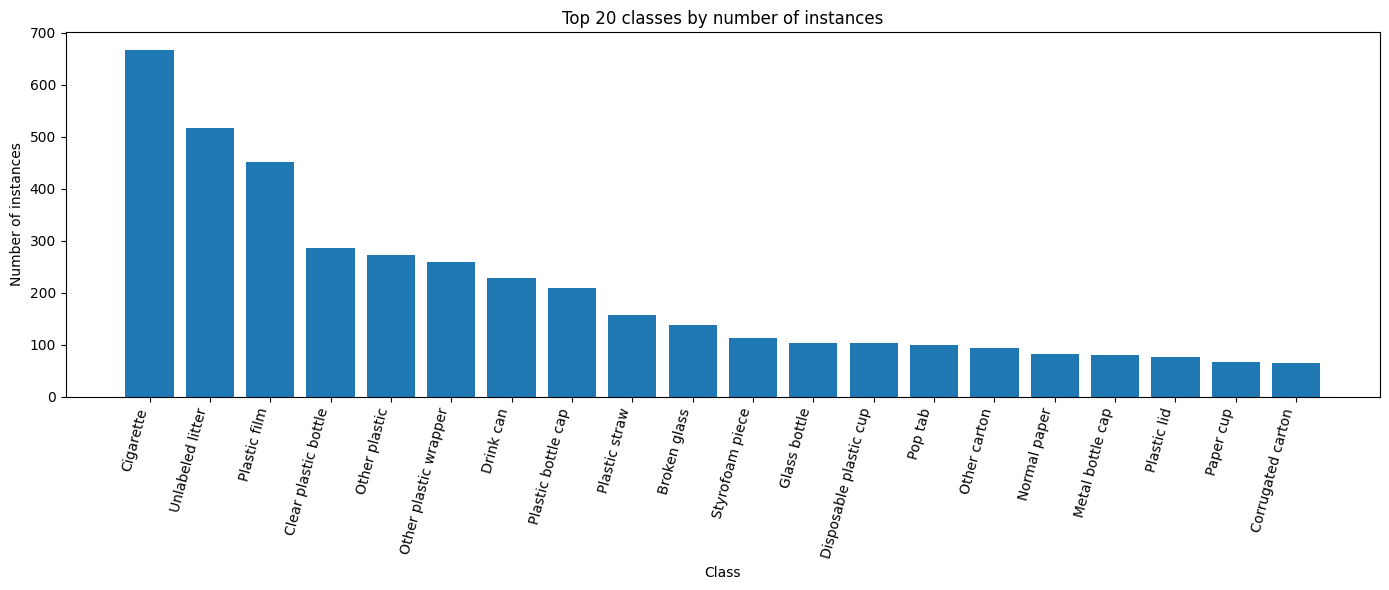

In [17]:
# Afisam distributia celor mai frecvente 20 clase

top_n = 20
top_classes = class_dist_df.head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(top_classes["class_name"], top_classes["total_count"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of instances")
plt.title(f"Top {top_n} classes by number of instances")
plt.tight_layout()
plt.show()

In [18]:
print("Number of classes:", len(class_dist_df))
print("Most frequent classes:")
display(class_dist_df.head(10))

print("Least frequent classes:")
display(class_dist_df.tail(10))

min_count = class_dist_df["total_count"].min()
max_count = class_dist_df["total_count"].max()
median_count = class_dist_df["total_count"].median()

print("Minimum class count:", min_count)
print("Maximum class count:", max_count)
print("Median class count:", median_count)

Number of classes: 59
Most frequent classes:


,class_name,train_count,valid_count,test_count,total_count
0,Cigarette,430,148,89,667
1,Unlabeled litter,374,93,50,517
2,Plastic film,310,81,60,451
3,Clear plastic bottle,217,50,18,285
4,Other plastic,201,39,33,273
5,Other plastic wrapper,196,34,29,259
6,Drink can,167,33,29,229
7,Plastic bottle cap,150,44,15,209
8,Plastic straw,121,24,12,157
9,Broken glass,92,15,31,138


Least frequent classes:


,class_name,train_count,valid_count,test_count,total_count
49,Glass cup,3,3,0,6
50,Toilet tube,4,1,0,5
51,Six pack rings,4,1,0,5
52,Tupperware,4,0,0,4
53,Paper straw,3,1,0,4
54,Plastic glooves,4,0,0,4
55,Pizza box,2,1,0,3
56,Polypropylene bag,2,0,1,3
57,Battery,1,1,0,2
58,Carded blister pack,1,0,0,1


Minimum class count: 1
Maximum class count: 667
Median class count: 34.0


## 2.5 Analiza distributiei claselor

Histograma arata dezechilibrul dintre clase: unele tipuri de deseuri apar mult mai des decat altele, ceea ce poate duce la performanta mai buna pe clasele frecvente si mai slaba pe clasele rare. Decizia de pastrare sau filtrare a claselor rare va fi justificata cantitativ in sectiunea de data cleaning.


In [19]:
def compute_objects_per_image(coco_data):
    objects_per_image = defaultdict(int)

    for ann in coco_data["annotations"]:
        objects_per_image[ann["image_id"]] += 1

    # includem si imaginile fara adnotari, daca exista
    all_image_ids = [img["id"] for img in coco_data["images"]]
    counts = [objects_per_image[image_id] for image_id in all_image_ids]

    return counts


train_objects_per_image = compute_objects_per_image(coco_train)
valid_objects_per_image = compute_objects_per_image(coco_valid)
test_objects_per_image = compute_objects_per_image(coco_test)

print("Train avg objects/image:", np.mean(train_objects_per_image))
print("Valid avg objects/image:", np.mean(valid_objects_per_image))
print("Test avg objects/image:", np.mean(test_objects_per_image))

print("Train max objects/image:", np.max(train_objects_per_image))
print("Valid max objects/image:", np.max(valid_objects_per_image))
print("Test max objects/image:", np.max(test_objects_per_image))

Train avg objects/image: 3.208728652751423
Valid avg objects/image: 2.9833333333333334
Test avg objects/image: 3.6133333333333333
Train max objects/image: 90
Valid max objects/image: 37
Test max objects/image: 30


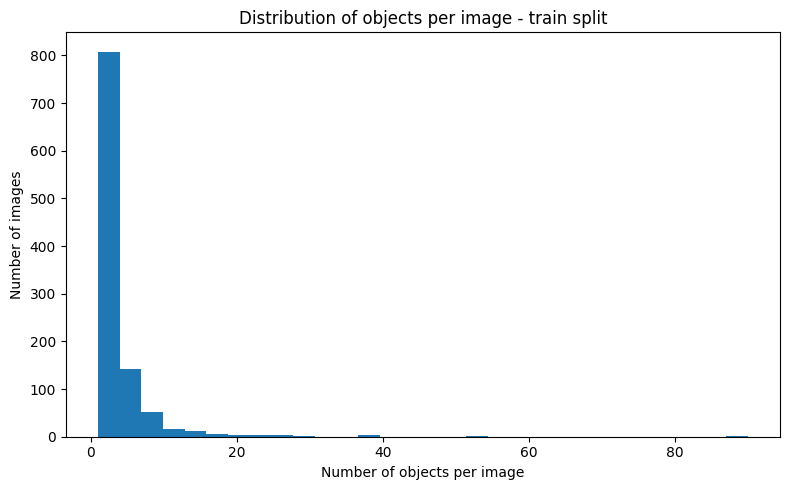

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(train_objects_per_image, bins=30)
plt.xlabel("Number of objects per image")
plt.ylabel("Number of images")
plt.title("Distribution of objects per image - train split")
plt.tight_layout()
plt.show()

## 2.6 Numarul mediu de obiecte per imagine

Media obiectelor per imagine indica dificultatea task-ului. Pentru instance segmentation, fiecare obiect necesita o clasa, un bounding box si o masca individuala; de aceea imaginile cu mai multe instante sunt mai dificile decat imaginile cu un singur obiect.


In [21]:
def compute_image_resolution_stats(coco_data):
    widths = []
    heights = []
    areas = []

    for img in coco_data["images"]:
        width = img["width"]
        height = img["height"]

        widths.append(width)
        heights.append(height)
        areas.append(width * height)

    stats = {
        "num_images": len(widths),
        "avg_width": np.mean(widths),
        "avg_height": np.mean(heights),
        "min_width": np.min(widths),
        "max_width": np.max(widths),
        "min_height": np.min(heights),
        "max_height": np.max(heights),
        "avg_area": np.mean(areas)
    }

    return stats, widths, heights, areas


resolution_stats_train, train_widths, train_heights, train_areas = compute_image_resolution_stats(coco_train)
resolution_stats_valid, valid_widths, valid_heights, valid_areas = compute_image_resolution_stats(coco_valid)
resolution_stats_test, test_widths, test_heights, test_areas = compute_image_resolution_stats(coco_test)

resolution_df = pd.DataFrame([
    {"split": "train", **resolution_stats_train},
    {"split": "valid", **resolution_stats_valid},
    {"split": "test", **resolution_stats_test}
])

resolution_df

,split,num_images,avg_width,avg_height,min_width,max_width,min_height,max_height,avg_area
0,train,1054,2854.102467,3237.809298,842,8160,474,8160,9.284189e+06
1,valid,300,2791.013333,3240.226667,1200,6000,960,5312,9.045135e+06
2,test,150,2790.226667,3228.686667,1200,6000,960,5312,9.102545e+06


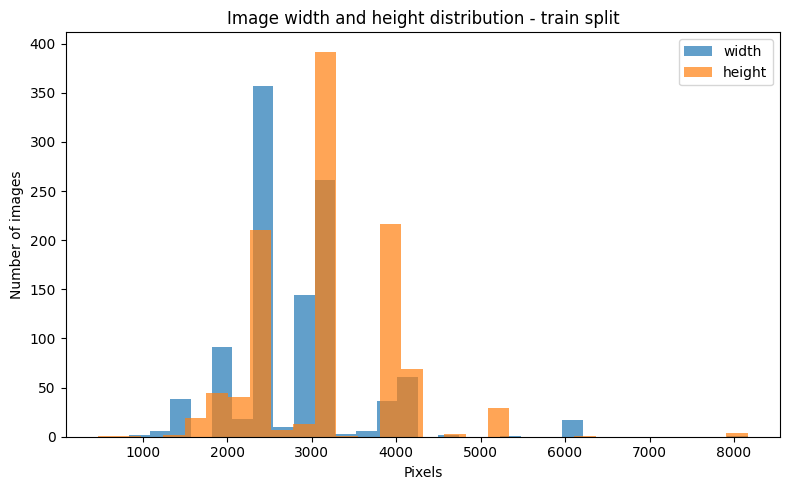

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(train_widths, bins=30, alpha=0.7, label="width")
plt.hist(train_heights, bins=30, alpha=0.7, label="height")
plt.xlabel("Pixels")
plt.ylabel("Number of images")
plt.title("Image width and height distribution - train split")
plt.legend()
plt.tight_layout()
plt.show()

## 2.7 Rezolutia imaginilor si trade-off-ul de resize

Rezolutia influenteaza direct memoria GPU si timpul de antrenare. Pe Google Colab T4 vom folosi un compromis practic: pastram suficient detaliu pentru obiectele mici, dar limitam dimensiunea imaginilor prin resize si batch size mic.


In [23]:
def check_annotation_quality(coco_data, split_name):
    missing_segmentation = 0
    empty_segmentation = 0
    invalid_bbox = 0
    invalid_area = 0
    total_annotations = len(coco_data["annotations"])

    for ann in coco_data["annotations"]:
        # Check segmentation
        if "segmentation" not in ann:
            missing_segmentation += 1
        else:
            segmentation = ann["segmentation"]
            if segmentation is None or len(segmentation) == 0:
                empty_segmentation += 1

        # Check bbox
        bbox = ann.get("bbox", None)
        if bbox is None or len(bbox) != 4:
            invalid_bbox += 1
        else:
            x, y, w, h = bbox
            if w <= 0 or h <= 0:
                invalid_bbox += 1

        # Check area
        area = ann.get("area", None)
        if area is None or area <= 0:
            invalid_area += 1

    return {
        "split": split_name,
        "total_annotations": total_annotations,
        "missing_segmentation": missing_segmentation,
        "empty_segmentation": empty_segmentation,
        "invalid_bbox": invalid_bbox,
        "invalid_area": invalid_area
    }


quality_stats = [
    check_annotation_quality(coco_train, "train"),
    check_annotation_quality(coco_valid, "valid"),
    check_annotation_quality(coco_test, "test")
]

quality_df = pd.DataFrame(quality_stats)
quality_df

,split,total_annotations,missing_segmentation,empty_segmentation,invalid_bbox,invalid_area
0,train,3382,0,0,0,0
1,valid,895,0,0,0,0
2,test,542,0,0,0,0


## 2.8 Calitatea labelurilor

Verificarea automata raporteaza adnotari fara `segmentation`, segmentari goale, bounding boxes invalide si arii invalide. Aceasta nu garanteaza ca toate mastile sunt perfecte, dar confirma integritatea de baza a labelurilor. Inspectia vizuala de mai jos completeaza verificarea automata.


In [24]:
train_ann_path = DATASET_DIR / "train" / "_annotations.coco.json"
coco_train_api = COCO(str(train_ann_path))

print("COCO API loaded.")
print("Images:", len(coco_train_api.imgs))
print("Categories:", len(coco_train_api.cats))
print("Annotations:", len(coco_train_api.anns))


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
COCO API loaded.
Images: 1054
Categories: 61
Annotations: 3382


In [25]:
def visualize_coco_sample(coco_api, image_dir, image_id=None, alpha=0.45):
    """
    Afiseaza o imagine COCO cu bounding boxes si masti de segmentare.
    """
    if image_id is None:
        image_id = random.choice(list(coco_api.imgs.keys()))

    image_info = coco_api.loadImgs(image_id)[0]
    image_path = Path(image_dir) / image_info["file_name"]

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = coco_api.loadAnns(ann_ids)

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image_np)

    for ann in anns:
        category_id = ann["category_id"]
        category_name = coco_api.cats[category_id]["name"]

        # Bounding box in COCO format: x, y, width, height
        x, y, w, h = ann["bbox"]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y,
            category_name,
            fontsize=9,
            bbox=dict(facecolor="yellow", alpha=0.6)
        )

        # Convert annotation polygon/RLE to binary mask
        mask = coco_api.annToMask(ann)

        # Create RGBA overlay: R, G, B, Alpha
        color = np.random.randint(0, 255, size=3)
        rgba_mask = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.uint8)
        rgba_mask[..., :3] = color
        rgba_mask[..., 3] = (mask * int(alpha * 255)).astype(np.uint8)

        ax.imshow(rgba_mask)

    ax.set_title(f"Image ID: {image_id} | Objects: {len(anns)}")
    ax.axis("off")
    plt.show()

In [26]:
train_image_dir = DATASET_DIR / "train"

random.seed(SEED)

existing_image_ids = []

for image_id, img_info in coco_train_api.imgs.items():
    image_path = train_image_dir / img_info["file_name"]

    if image_path.exists():
        existing_image_ids.append(image_id)

print(f"Imagini existente gasite: {len(existing_image_ids)} / {len(coco_train_api.imgs)}")

sample_image_ids = random.sample(existing_image_ids, min(5, len(existing_image_ids)))

for image_id in sample_image_ids:
    visualize_coco_sample(coco_train_api, train_image_dir, image_id=image_id)

Output hidden; open in https://colab.research.google.com to view.

## 2.9 Exemple vizuale adnotate

Cele 5 exemple vizuale extrase din setul de train confirma ca imaginile si adnotarile au fost incarcate corect. Se observa obiecte din clase diferite, cu bounding box-uri si masti suprapuse peste imagine, ceea ce valideaza structura COCO folosita in proiect. Exemplele arata si dificultatea datasetului: obiectele sunt mici, partial ascunse sau apar pe fundaluri aglomerate.

In [27]:
total_images = sum(split_stats_df["num_images"])
total_annotations = sum(split_stats_df["num_annotations"])
avg_objects_global = total_annotations / total_images

avg_width_global = np.mean(train_widths + valid_widths + test_widths)
avg_height_global = np.mean(train_heights + valid_heights + test_heights)

num_classes = len(class_dist_df)

feasibility_summary = {
    "total_images": total_images,
    "total_annotations": total_annotations,
    "num_classes": num_classes,
    "avg_objects_per_image": avg_objects_global,
    "avg_width": avg_width_global,
    "avg_height": avg_height_global,
    "gpu_used": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "task": "Instance Segmentation",
    "dataset_format": "COCO Segmentation"
}

feasibility_summary

{'total_images': 1504,
 'total_annotations': 4819,
 'num_classes': 59,
 'avg_objects_per_image': 3.204122340425532,
 'avg_width': np.float64(2835.1476063829787),
 'avg_height': np.float64(3237.38164893617),
 'gpu_used': 'Tesla T4',
 'task': 'Instance Segmentation',
 'dataset_format': 'COCO Segmentation'}

In [28]:
feasibility_df = pd.DataFrame([
    {"Aspect": "Total images", "Value": total_images},
    {"Aspect": "Total annotations", "Value": total_annotations},
    {"Aspect": "Number of classes", "Value": num_classes},
    {"Aspect": "Average objects per image", "Value": round(avg_objects_global, 2)},
    {"Aspect": "Average image width", "Value": round(avg_width_global, 2)},
    {"Aspect": "Average image height", "Value": round(avg_height_global, 2)},
    {"Aspect": "Compute device", "Value": feasibility_summary["gpu_used"]},
    {"Aspect": "Task", "Value": "Instance Segmentation"},
    {"Aspect": "Format", "Value": "COCO Segmentation"},
])

feasibility_df

,Aspect,Value
0,Total images,1504
1,Total annotations,4819
2,Number of classes,59
3,Average objects per image,3.2
4,Average image width,2835.15
5,Average image height,3237.38
6,Compute device,Tesla T4
7,Task,Instance Segmentation
8,Format,COCO Segmentation


## 2.10 Concluzie asupra fezabilitatii

Dataset-ul TACO Trash Segmentation indeplineste cerintele sectiunii 2: este real, este adnotat pentru instance segmentation, include exemple vizuale si permite o analiza cantitativa a claselor, obiectelor pe imagine, rezolutiei si labelurilor.

Fezabilitatea este buna pentru Google Colab T4 deoarece dataset-ul nu este foarte mare, iar costul computational poate fi controlat prin resize, batch size mic si folosirea unui model pre-antrenat. Principala limita observata este dezechilibrul intre clase, care va fi tratat in etapa de data cleaning si preprocessing.


# 3. Data Cleaning & Preprocessing

In aceasta sectiune curatam si pregatim dataset-ul pentru antrenarea modelului Mask R-CNN.

Obiective:
1. Analizam distributia claselor si decidem ce clase pastram.
2. Justificam cantitativ pragul ales pentru filtrarea claselor.
3. Verificam integritatea dataset-ului:
   - imagini lipsa sau corupte;
   - adnotari fara segmentare;
   - bounding boxes invalide;
   - imagini fara label-uri;
   - duplicate.
4. Definim pipeline-ul de preprocessing:
   - conversie imagine in tensor;
   - scalare valori pixeli in intervalul [0, 1];
   - resize controlat pentru antrenare;
   - normalizare cu mean/std;
   - conversie label-uri COCO in label-uri consecutive pentru PyTorch.

## 3.1 Strategie generala

Dataset-ul TACO contine multe clase, iar unele pot avea foarte putine instante. Daca pastram toate clasele, modelul poate invata greu clasele rare, iar antrenarea devine mai instabila.

Pentru acest proiect vom folosi o strategie practica:

- calculam numarul total de instante pentru fiecare clasa;
- pastram doar clasele cu un numar suficient de instante;
- pentru a mentine antrenarea fezabila pe Google Colab T4, limitam numarul final de clase;
- eliminam din adnotari obiectele care apartin claselor nepastrate;
- eliminam imaginile care raman fara nicio adnotare valida dupa filtrare.

Aceasta abordare reduce dezechilibrul si face task-ul mai realist pentru timpul si resursele disponibile.

In [29]:
# Configurare pentru Data Cleaning & Preprocessing
if "SEED" not in globals():
    SEED = 42
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/content/drive/MyDrive/ProiectD3") if IN_COLAB else Path.cwd()
if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "data"
if "DATASET_DIR" not in globals():
    DATASET_DIR = DATA_DIR / "TACO-Trash-Segmentation-1"
if "OUTPUTS_DIR" not in globals():
    OUTPUTS_DIR = PROJECT_ROOT / "outputs"

DATASET_DIR = Path(DATASET_DIR)
OUTPUTS_DIR = Path(OUTPUTS_DIR)
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}. Ruleaza mai intai celula de download din Roboflow.")

SPLITS = ["train", "valid", "test"]
CLEAN_OUTPUT_DIR = OUTPUTS_DIR / "cleaned_annotations"
CLEAN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)
print("CLEAN_OUTPUT_DIR:", CLEAN_OUTPUT_DIR)
print("Seed:", SEED)

PROJECT_ROOT: /content/drive/MyDrive/ProiectD3
DATASET_DIR: /content/drive/MyDrive/ProiectD3/data/TACO-Trash-Segmentation-1
OUTPUTS_DIR: /content/drive/MyDrive/ProiectD3/outputs
CLEAN_OUTPUT_DIR: /content/drive/MyDrive/ProiectD3/outputs/cleaned_annotations
Seed: 42


In [30]:
def get_annotation_path(split):
    return DATASET_DIR / split / "_annotations.coco.json"


def get_split_dir(split):
    return DATASET_DIR / split


def load_coco_json(split):
    ann_path = get_annotation_path(split)

    if not ann_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {ann_path}")

    with open(ann_path, "r") as f:
        return json.load(f)


def save_json(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def is_valid_segmentation(segmentation):
    if segmentation is None:
        return False

    if isinstance(segmentation, list):
        return len(segmentation) > 0

    if isinstance(segmentation, dict):
        return "counts" in segmentation and "size" in segmentation

    return False


def is_valid_bbox(bbox):
    if bbox is None or len(bbox) != 4:
        return False

    x, y, w, h = bbox
    return w > 0 and h > 0


def image_md5(path, chunk_size=8192):
    hash_md5 = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()

In [31]:
raw_coco = {split: load_coco_json(split) for split in SPLITS}

for split in SPLITS:
    print(f"\nSplit: {split}")
    print("Images:", len(raw_coco[split]["images"]))
    print("Annotations:", len(raw_coco[split]["annotations"]))
    print("Categories:", len(raw_coco[split]["categories"]))


Split: train
Images: 1054
Annotations: 3382
Categories: 61

Split: valid
Images: 300
Annotations: 895
Categories: 61

Split: test
Images: 150
Annotations: 542
Categories: 61


In [32]:
# Construim mapping category_id -> class_name.
# Presupunem ca lista de categorii este aceeasi pentru toate split-urile.

categories_raw = raw_coco["train"]["categories"]
cat_id_to_name = {cat["id"]: cat["name"] for cat in categories_raw}
cat_name_to_id = {cat["name"]: cat["id"] for cat in categories_raw}

def compute_class_counts_by_split(raw_coco):
    rows = []

    all_class_names = sorted(cat_name_to_id.keys())

    for class_name in all_class_names:
        old_cat_id = cat_name_to_id[class_name]
        row = {
            "old_category_id": old_cat_id,
            "class_name": class_name
        }

        total = 0
        for split in SPLITS:
            count = sum(
                1 for ann in raw_coco[split]["annotations"]
                if ann["category_id"] == old_cat_id
            )
            row[f"{split}_count"] = count
            total += count

        row["total_count"] = total
        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.sort_values("total_count", ascending=False).reset_index(drop=True)
    return df


raw_class_distribution_df = compute_class_counts_by_split(raw_coco)

print("Number of original classes:", len(raw_class_distribution_df))
display(raw_class_distribution_df.head(20))

Number of original classes: 61


,old_category_id,class_name,train_count,valid_count,test_count,total_count
0,7,Cigarette,430,148,89,667
1,59,Unlabeled litter,374,93,50,517
2,40,Plastic film,310,81,60,451
3,8,Clear plastic bottle,217,50,18,285
4,30,Other plastic,201,39,33,273
5,34,Other plastic wrapper,196,34,29,259
6,13,Drink can,167,33,29,229
7,39,Plastic bottle cap,150,44,15,209
8,43,Plastic straw,121,24,12,157
9,5,Broken glass,92,15,31,138


In [33]:
# Praguri alese pentru proiect.
# MIN_INSTANCES_PER_CLASS reduce clasele foarte rare.
# MAX_CLASSES_TO_KEEP limiteaza complexitatea pentru Colab T4.

MIN_INSTANCES_PER_CLASS = 25
MAX_CLASSES_TO_KEEP = 10

eligible_classes_df = raw_class_distribution_df[
    raw_class_distribution_df["total_count"] >= MIN_INSTANCES_PER_CLASS
].copy()

selected_classes_df = eligible_classes_df.head(MAX_CLASSES_TO_KEEP).copy()

selected_old_category_ids = selected_classes_df["old_category_id"].tolist()
selected_class_names = selected_classes_df["class_name"].tolist()

print("Minimum instances per class:", MIN_INSTANCES_PER_CLASS)
print("Maximum classes to keep:", MAX_CLASSES_TO_KEEP)
print("Eligible classes:", len(eligible_classes_df))
print("Selected classes:", len(selected_classes_df))

display(selected_classes_df)

Minimum instances per class: 25
Maximum classes to keep: 10
Eligible classes: 34
Selected classes: 10


,old_category_id,class_name,train_count,valid_count,test_count,total_count
0,7,Cigarette,430,148,89,667
1,59,Unlabeled litter,374,93,50,517
2,40,Plastic film,310,81,60,451
3,8,Clear plastic bottle,217,50,18,285
4,30,Other plastic,201,39,33,273
5,34,Other plastic wrapper,196,34,29,259
6,13,Drink can,167,33,29,229
7,39,Plastic bottle cap,150,44,15,209
8,43,Plastic straw,121,24,12,157
9,5,Broken glass,92,15,31,138


## 3.2 Justificarea pastrarii claselor

Pentru a reduce dezechilibrul sever dintre clase si pentru a face antrenarea fezabila pe Google Colab T4, pastram doar clasele cu cel putin `MIN_INSTANCES_PER_CLASS` instante in intregul dataset.

In plus, limitam numarul final de clase la `MAX_CLASSES_TO_KEEP`, selectand cele mai frecvente clase eligibile. In rularea curenta, aceasta alegere pastreaza majoritatea adnotarilor utile pentru clasele frecvente, dar reduce mult complexitatea problemei fata de cele 61 categorii COCO initiale.

Aceasta decizie are urmatoarele efecte:
- reduce numarul de clase rare;
- creste sansele ca modelul sa invete reprezentari utile pentru fiecare clasa pastrata;
- reduce complexitatea head-ului de clasificare;
- scade timpul de antrenare;
- face evaluarea mai stabila.

Clasa `background` nu exista explicit in COCO, dar va fi adaugata implicit de modelul Mask R-CNN la indexul 0. Clasele selectate vor fi remapate la id-uri consecutive incepand de la 1.


In [34]:
before_total_annotations = raw_class_distribution_df["total_count"].sum()
after_total_annotations = selected_classes_df["total_count"].sum()

before_num_classes = len(raw_class_distribution_df)
after_num_classes = len(selected_classes_df)

filtering_effect_df = pd.DataFrame([
    {
        "Metric": "Number of classes",
        "Before filtering": before_num_classes,
        "After filtering": after_num_classes,
        "Removed": before_num_classes - after_num_classes,
        "Retained (%)": round(after_num_classes / before_num_classes * 100, 2)
    },
    {
        "Metric": "Number of annotations",
        "Before filtering": before_total_annotations,
        "After filtering": after_total_annotations,
        "Removed": before_total_annotations - after_total_annotations,
        "Retained (%)": round(after_total_annotations / before_total_annotations * 100, 2)
    }
])

filtering_effect_df


,Metric,Before filtering,After filtering,Removed,Retained (%)
0,Number of classes,61,10,51,16.39
1,Number of annotations,4819,3185,1634,66.09


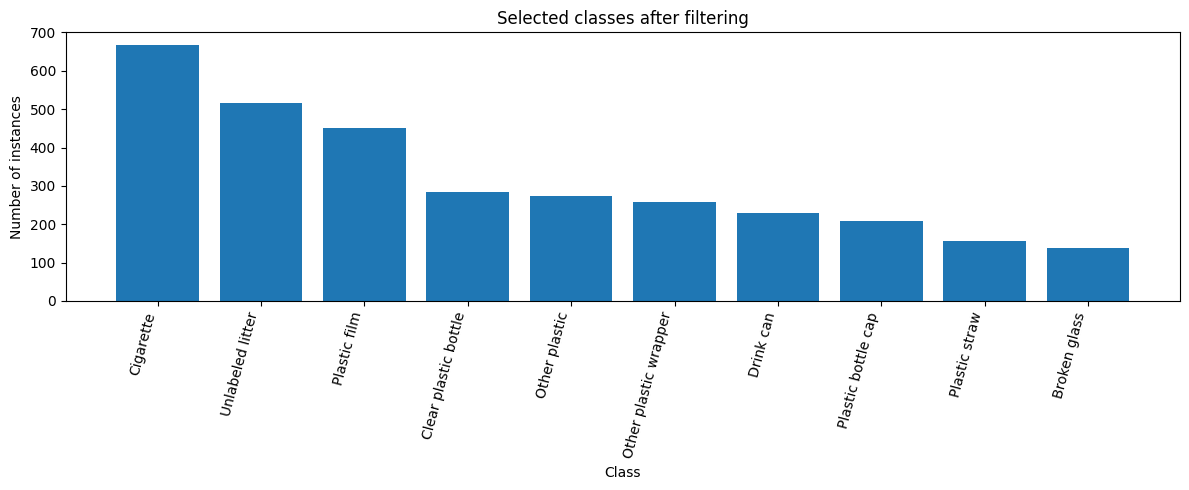

In [35]:
plt.figure(figsize=(12, 5))
plt.bar(selected_classes_df["class_name"], selected_classes_df["total_count"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of instances")
plt.title("Selected classes after filtering")
plt.tight_layout()
plt.show()

In [36]:
# Verificare integritate imagini. Modul complet este lasat dezactivat pentru predarea finala.
CHECK_IMAGE_CORRUPTION = False       # True = Image.open(...).verify(), detecteaza fisiere imagine corupte
CHECK_DUPLICATES_BY_HASH = False     # True = MD5 pe continut, detecteaza duplicate reale inclusiv intre split-uri


FULL_INTEGRITY_MODE = CHECK_IMAGE_CORRUPTION and CHECK_DUPLICATES_BY_HASH
print("Full image integrity mode:", FULL_INTEGRITY_MODE)


def image_md5(path, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


def inspect_images_and_duplicates(raw_coco, check_corruption=False, check_hash_duplicates=False):
    records = []
    for split in SPLITS:
        split_dir = get_split_dir(split)
        for img in raw_coco[split]["images"]:
            image_id = img["id"]
            file_name = img["file_name"]
            image_path = split_dir / file_name
            exists = image_path.exists()
            is_corrupt = False
            digest = None

            if exists and check_corruption:
                try:
                    with Image.open(image_path) as opened:
                        opened.verify()
                except Exception:
                    is_corrupt = True

            if exists and check_hash_duplicates:
                digest = image_md5(image_path)

            records.append({
                "split": split,
                "image_id": image_id,
                "file_name": file_name,
                "path": str(image_path),
                "exists": exists,
                "is_corrupt": is_corrupt,
                "md5": digest,
            })

    image_df = pd.DataFrame(records)
    missing_image_keys = set((row["split"], row["image_id"]) for _, row in image_df.iterrows() if not row["exists"])
    corrupt_image_keys = set((row["split"], row["image_id"]) for _, row in image_df.iterrows() if row["is_corrupt"])

    duplicate_column = "md5" if check_hash_duplicates else "file_name"
    duplicate_source = image_df[image_df[duplicate_column].notna()] if check_hash_duplicates else image_df
    duplicated = duplicate_source[duplicate_source.duplicated(subset=[duplicate_column], keep=False)]

    duplicate_groups = []
    duplicate_keys_to_remove = set()
    for duplicate_value, group in duplicated.groupby(duplicate_column):
        records_group = list(zip(group["split"], group["image_id"], group["file_name"]))
        if len(records_group) > 1:
            duplicate_groups.append({"duplicate_key": duplicate_value, "num_duplicates": len(records_group), "records": records_group})
            for split, image_id, _ in records_group[1:]:
                duplicate_keys_to_remove.add((split, image_id))

    return image_df, duplicate_groups, duplicate_keys_to_remove, missing_image_keys, corrupt_image_keys


image_integrity_df, duplicate_groups, duplicate_keys_to_remove, missing_image_keys, corrupt_image_keys = inspect_images_and_duplicates(
    raw_coco,
    check_corruption=CHECK_IMAGE_CORRUPTION,
    check_hash_duplicates=CHECK_DUPLICATES_BY_HASH,
)

integrity_image_summary = pd.DataFrame([
    {"Issue": "Missing image files", "Count": len(missing_image_keys), "Method": "path.exists"},
    {"Issue": "Corrupt image files", "Count": len(corrupt_image_keys), "Method": "PIL Image.verify" if CHECK_IMAGE_CORRUPTION else "not checked"},
    {"Issue": "Duplicate image groups", "Count": len(duplicate_groups), "Method": "MD5 content hash" if CHECK_DUPLICATES_BY_HASH else "file name"},
    {"Issue": "Duplicate images to remove", "Count": len(duplicate_keys_to_remove), "Method": "keep first occurrence"},
])
show_table(integrity_image_summary, "Image integrity check")

if len(duplicate_groups) > 0:
    duplicate_preview_df = pd.DataFrame([
        {"duplicate_key": group["duplicate_key"], "num_duplicates": group["num_duplicates"], "examples": group["records"][:3]}
        for group in duplicate_groups[:10]
    ])
    show_table(duplicate_preview_df, "Duplicate preview")
else:
    print("No duplicate image groups found with the selected method.")


Full image integrity mode: False


,Issue,Count,Method
0,Missing image files,0.0000,path.exists
1,Corrupt image files,0.0000,not checked
2,Duplicate image groups,0.0000,file name
3,Duplicate images to remove,0.0000,keep first occurrence


No duplicate image groups found with the selected method.


Pentru predarea finala am dezactivat verificarea completa: `CHECK_IMAGE_CORRUPTION=False` si `CHECK_DUPLICATES_BY_HASH=False`.
Am realizat o rulare si cu flag-urile active pe `True` dar ruleaza destul de mult (aprox 20-30 min) iar rezultatul este ca nu avem imagini corupte.

Tabelul `Image integrity check` se citeste astfel: prima linie confirma daca lipsesc fisiere din folderele de split, a doua linie raporteaza imagini care nu pot fi deschise/validate, iar ultimele doua linii arata daca exista grupuri duplicate si cate imagini ar fi eliminate pastrand prima aparitie. In rularea completa efectuata pentru predare, rezultatul a ramas fara probleme de integritate.


In [37]:
def inspect_annotations(raw_coco):
    rows = []

    for split in SPLITS:
        coco_data = raw_coco[split]
        image_ids = set(img["id"] for img in coco_data["images"])

        annotations_by_image = defaultdict(list)
        for ann in coco_data["annotations"]:
            annotations_by_image[ann["image_id"]].append(ann)

        images_without_annotations = [
            img_id for img_id in image_ids
            if len(annotations_by_image[img_id]) == 0
        ]

        missing_segmentation = 0
        invalid_bbox = 0
        invalid_area = 0
        annotation_references_missing_image = 0

        for ann in coco_data["annotations"]:
            if ann["image_id"] not in image_ids:
                annotation_references_missing_image += 1

            if not is_valid_segmentation(ann.get("segmentation", None)):
                missing_segmentation += 1

            if not is_valid_bbox(ann.get("bbox", None)):
                invalid_bbox += 1

            if ann.get("area", 0) <= 0:
                invalid_area += 1

        rows.append({
            "split": split,
            "images": len(coco_data["images"]),
            "annotations": len(coco_data["annotations"]),
            "images_without_annotations": len(images_without_annotations),
            "missing_or_empty_segmentation": missing_segmentation,
            "invalid_bbox": invalid_bbox,
            "invalid_area": invalid_area,
            "annotations_referencing_missing_image": annotation_references_missing_image
        })

    return pd.DataFrame(rows)


annotation_integrity_df = inspect_annotations(raw_coco)
annotation_integrity_df

,split,images,annotations,images_without_annotations,missing_or_empty_segmentation,invalid_bbox,invalid_area,annotations_referencing_missing_image
0,train,1054,3382,0,0,0,0,0
1,valid,300,895,0,0,0,0,0
2,test,150,542,0,0,0,0,0


## 3.3 Verificarea integritatii datelor

Am verificat integritatea dataset-ului din doua perspective:

### Integritatea imaginilor
- fisiere imagine lipsa;
- imagini corupte;
- duplicate pe baza de hash MD5, inclusiv intre split-uri.

### Integritatea adnotarilor
- imagini fara adnotari;
- adnotari fara segmentare;
- bounding boxes invalide;
- arii invalide;
- adnotari care refera imagini inexistente.

Imaginile corupte, imaginile lipsa si duplicatele sunt eliminate din varianta curatata a dataset-ului. De asemenea, adnotarile invalide sunt eliminate inainte de salvarea fisierelor COCO curatate.


### Rezultatele verificarii integritatii

Tabelele de mai sus raporteaza cifrele concrete pentru problemele gasite in dataset. In rularea curenta nu apar probleme structurale majore: nu sunt raportate imagini lipsa, imagini corupte, duplicate sau adnotari invalide.

Aceasta verificare este importanta deoarece filtrarea claselor trebuie separata de curatarea datelor: eliminam clase rare pentru fezabilitate, dar eliminam imagini/adnotari doar daca sunt invalide sau nu mai contin obiecte din clasele pastrate.


In [38]:
# Remapare: COCO category_id original -> id nou consecutiv pentru PyTorch.
# 0 este rezervat pentru background.

old_id_to_new_id = {
    old_id: new_id
    for new_id, old_id in enumerate(selected_old_category_ids, start=1)
}

new_id_to_class_name = {
    new_id: cat_id_to_name[old_id]
    for old_id, new_id in old_id_to_new_id.items()
}

clean_categories = [
    {
        "id": new_id,
        "name": new_id_to_class_name[new_id],
        "supercategory": "trash"
    }
    for new_id in sorted(new_id_to_class_name.keys())
]

print("Old category id -> new category id:")
for old_id, new_id in old_id_to_new_id.items():
    print(f"{old_id} ({cat_id_to_name[old_id]}) -> {new_id}")

print("\nNumber of foreground classes:", len(clean_categories))
print("Number of model classes including background:", len(clean_categories) + 1)

Old category id -> new category id:
7 (Cigarette) -> 1
59 (Unlabeled litter) -> 2
40 (Plastic film) -> 3
8 (Clear plastic bottle) -> 4
30 (Other plastic) -> 5
34 (Other plastic wrapper) -> 6
13 (Drink can) -> 7
39 (Plastic bottle cap) -> 8
43 (Plastic straw) -> 9
5 (Broken glass) -> 10

Number of foreground classes: 10
Number of model classes including background: 11


In [39]:
def clean_coco_split(
    coco_data,
    split,
    selected_old_category_ids,
    old_id_to_new_id,
    duplicate_keys_to_remove,
    missing_image_keys,
    corrupt_image_keys
):
    """
    Curata un split COCO:
    - elimina imagini lipsa/corupte/duplicate;
    - elimina adnotari invalide;
    - elimina clasele nepastrate;
    - remapeaza category_id la valori consecutive;
    - elimina imaginile ramase fara adnotari valide.
    """
    selected_old_category_ids = set(selected_old_category_ids)

    excluded_image_keys = set()
    excluded_image_keys.update(duplicate_keys_to_remove)
    excluded_image_keys.update(missing_image_keys)
    excluded_image_keys.update(corrupt_image_keys)

    image_id_to_image = {img["id"]: img for img in coco_data["images"]}

    valid_annotations_by_image = defaultdict(list)

    removal_counters = Counter()

    for ann in coco_data["annotations"]:
        image_id = ann["image_id"]
        image_key = (split, image_id)

        if image_key in excluded_image_keys:
            removal_counters["annotations_removed_due_to_bad_image"] += 1
            continue

        if image_id not in image_id_to_image:
            removal_counters["annotations_removed_missing_image_reference"] += 1
            continue

        if ann["category_id"] not in selected_old_category_ids:
            removal_counters["annotations_removed_due_to_class_filter"] += 1
            continue

        if not is_valid_bbox(ann.get("bbox", None)):
            removal_counters["annotations_removed_invalid_bbox"] += 1
            continue

        if not is_valid_segmentation(ann.get("segmentation", None)):
            removal_counters["annotations_removed_invalid_segmentation"] += 1
            continue

        if ann.get("area", 0) <= 0:
            removal_counters["annotations_removed_invalid_area"] += 1
            continue

        new_ann = ann.copy()
        new_ann["category_id"] = old_id_to_new_id[ann["category_id"]]

        valid_annotations_by_image[image_id].append(new_ann)

    clean_images = []
    clean_annotations = []
    new_ann_id = 1

    for image_id, img in image_id_to_image.items():
        image_key = (split, image_id)

        if image_key in excluded_image_keys:
            removal_counters["images_removed_bad_or_duplicate"] += 1
            continue

        image_annotations = valid_annotations_by_image.get(image_id, [])

        if len(image_annotations) == 0:
            removal_counters["images_removed_without_valid_annotations"] += 1
            continue

        clean_images.append(img)

        for ann in image_annotations:
            ann = ann.copy()
            ann["id"] = new_ann_id
            clean_annotations.append(ann)
            new_ann_id += 1

    clean_coco_data = {
        "info": coco_data.get("info", {}),
        "licenses": coco_data.get("licenses", []),
        "categories": clean_categories,
        "images": clean_images,
        "annotations": clean_annotations
    }

    summary = {
        "split": split,
        "raw_images": len(coco_data["images"]),
        "raw_annotations": len(coco_data["annotations"]),
        "clean_images": len(clean_images),
        "clean_annotations": len(clean_annotations),
        "removed_images": len(coco_data["images"]) - len(clean_images),
        "removed_annotations": len(coco_data["annotations"]) - len(clean_annotations),
        **dict(removal_counters)
    }

    return clean_coco_data, summary


clean_coco = {}
cleaning_summaries = []

for split in SPLITS:
    clean_data, summary = clean_coco_split(
        coco_data=raw_coco[split],
        split=split,
        selected_old_category_ids=selected_old_category_ids,
        old_id_to_new_id=old_id_to_new_id,
        duplicate_keys_to_remove=duplicate_keys_to_remove,
        missing_image_keys=missing_image_keys,
        corrupt_image_keys=corrupt_image_keys
    )

    clean_coco[split] = clean_data
    cleaning_summaries.append(summary)

cleaning_summary_df = pd.DataFrame(cleaning_summaries)
cleaning_summary_df

,split,raw_images,raw_annotations,clean_images,clean_annotations,removed_images,removed_annotations,annotations_removed_due_to_class_filter,images_removed_without_valid_annotations
0,train,1054,3382,782,2258,272,1124,1124,272
1,valid,300,895,225,561,75,334,334,75
2,test,150,542,116,366,34,176,176,34


In [40]:
clean_annotation_paths = {}

for split in SPLITS:
    output_path = CLEAN_OUTPUT_DIR / f"{split}_cleaned.coco.json"
    save_json(clean_coco[split], output_path)
    clean_annotation_paths[split] = output_path
    print(f"Saved cleaned annotations for {split}: {output_path}")

Saved cleaned annotations for train: /content/drive/MyDrive/ProiectD3/outputs/cleaned_annotations/train_cleaned.coco.json
Saved cleaned annotations for valid: /content/drive/MyDrive/ProiectD3/outputs/cleaned_annotations/valid_cleaned.coco.json
Saved cleaned annotations for test: /content/drive/MyDrive/ProiectD3/outputs/cleaned_annotations/test_cleaned.coco.json


In [41]:
def compute_clean_class_distribution(clean_coco):
    rows = []

    for cat in clean_categories:
        new_cat_id = cat["id"]
        class_name = cat["name"]

        row = {
            "new_category_id": new_cat_id,
            "class_name": class_name
        }

        total = 0
        for split in SPLITS:
            count = sum(
                1 for ann in clean_coco[split]["annotations"]
                if ann["category_id"] == new_cat_id
            )
            row[f"{split}_count"] = count
            total += count

        row["total_count"] = total
        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.sort_values("total_count", ascending=False).reset_index(drop=True)
    return df


clean_class_distribution_df = compute_clean_class_distribution(clean_coco)
clean_class_distribution_df

,new_category_id,class_name,train_count,valid_count,test_count,total_count
0,1,Cigarette,430,148,89,667
1,2,Unlabeled litter,374,93,50,517
2,3,Plastic film,310,81,60,451
3,4,Clear plastic bottle,217,50,18,285
4,5,Other plastic,201,39,33,273
5,6,Other plastic wrapper,196,34,29,259
6,7,Drink can,167,33,29,229
7,8,Plastic bottle cap,150,44,15,209
8,9,Plastic straw,121,24,12,157
9,10,Broken glass,92,15,31,138


In [42]:
final_effect_df = pd.DataFrame([
    {
        "Metric": "Classes",
        "Before": len(raw_class_distribution_df),
        "After": len(clean_class_distribution_df),
        "Removed": len(raw_class_distribution_df) - len(clean_class_distribution_df)
    },
    {
        "Metric": "Train images",
        "Before": len(raw_coco["train"]["images"]),
        "After": len(clean_coco["train"]["images"]),
        "Removed": len(raw_coco["train"]["images"]) - len(clean_coco["train"]["images"])
    },
    {
        "Metric": "Valid images",
        "Before": len(raw_coco["valid"]["images"]),
        "After": len(clean_coco["valid"]["images"]),
        "Removed": len(raw_coco["valid"]["images"]) - len(clean_coco["valid"]["images"])
    },
    {
        "Metric": "Test images",
        "Before": len(raw_coco["test"]["images"]),
        "After": len(clean_coco["test"]["images"]),
        "Removed": len(raw_coco["test"]["images"]) - len(clean_coco["test"]["images"])
    },
    {
        "Metric": "Total annotations",
        "Before": sum(len(raw_coco[s]["annotations"]) for s in SPLITS),
        "After": sum(len(clean_coco[s]["annotations"]) for s in SPLITS),
        "Removed": sum(len(raw_coco[s]["annotations"]) for s in SPLITS) - sum(len(clean_coco[s]["annotations"]) for s in SPLITS)
    }
])

final_effect_df

,Metric,Before,After,Removed
0,Classes,61,10,51
1,Train images,1054,782,272
2,Valid images,300,225,75
3,Test images,150,116,34
4,Total annotations,4819,3185,1634


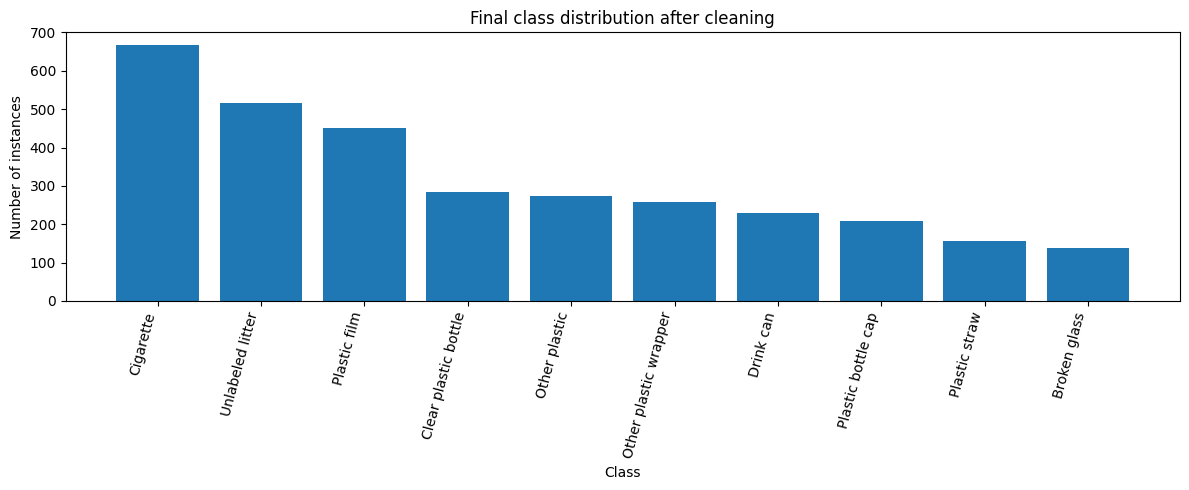

In [43]:
plt.figure(figsize=(12, 5))
plt.bar(clean_class_distribution_df["class_name"], clean_class_distribution_df["total_count"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of instances")
plt.title("Final class distribution after cleaning")
plt.tight_layout()
plt.show()

## 3.4 Rezultatul filtrarii claselor

Dupa filtrare, dataset-ul contine doar clasele cele mai reprezentate. Decizia este justificata cantitativ prin numarul de instante per clasa si prin procentul de adnotari pastrate dupa filtrare.

Efectul filtrarii este vizibil in tabelele de mai sus:
- numarul de clase este redus la un set mai usor de antrenat;
- o parte dintre adnotari este eliminata deoarece apartine claselor rare;
- imaginile care nu mai contin obiecte din clasele selectate sunt eliminate;
- distributia finala este mai potrivita pentru antrenare pe un GPU T4.

Aceasta strategie reduce riscul ca modelul sa fie dominat de clase foarte rare sau de clase cu prea putine exemple pentru a fi invatate corect.


In [44]:
def compute_split_ratios(clean_coco):
    total_images = sum(len(clean_coco[split]["images"]) for split in SPLITS)

    rows = []
    for split in SPLITS:
        count = len(clean_coco[split]["images"])
        ratio = count / total_images if total_images > 0 else 0

        rows.append({
            "split": split,
            "images": count,
            "ratio": round(ratio, 4),
            "percentage": f"{ratio * 100:.2f}%"
        })

    return pd.DataFrame(rows)


split_ratio_df = compute_split_ratios(clean_coco)

print("Seed used:", SEED)
display(split_ratio_df)

Seed used: 42


,split,images,ratio,percentage
0,train,782,0.6963,69.63%
1,valid,225,0.2004,20.04%
2,test,116,0.1033,10.33%


## 3.5 Split train / validation / test

Dataset-ul este deja impartit in trei subseturi:
- train;
- validation;
- test.

Am pastrat aceasta impartire pentru a evita amestecarea datelor si pentru a mentine o evaluare corecta. Setul de train este folosit pentru antrenare, setul de validation pentru monitorizarea performantei in timpul dezvoltarii, iar setul de test pentru evaluarea finala.

Seed-ul folosit in notebook este afisat mai sus si este pastrat constant pentru reproductibilitate.

In [45]:
# Configurare preprocessing pentru Mask R-CNN

IMAGE_SIZE = 512

# Mean si std standard ImageNet, folosite frecvent pentru backbone-uri pre-antrenate.
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]

PREPROCESSING_CONFIG = {
    "image_size": IMAGE_SIZE,
    "pixel_scaling": "[0, 255] -> [0, 1]",
    "normalization_mean": IMAGE_MEAN,
    "normalization_std": IMAGE_STD,
    "label_mapping": "COCO category_id -> consecutive ids starting from 1",
    "background_class": 0,
    "num_foreground_classes": len(clean_categories),
    "num_model_classes": len(clean_categories) + 1,
    "resize_strategy": "LongestMaxSize + PadIfNeeded to IMAGE_SIZE, without aspect-ratio distortion",
}

PREPROCESSING_CONFIG


{'image_size': 512,
 'pixel_scaling': '[0, 255] -> [0, 1]',
 'normalization_mean': [0.485, 0.456, 0.406],
 'normalization_std': [0.229, 0.224, 0.225],
 'label_mapping': 'COCO category_id -> consecutive ids starting from 1',
 'background_class': 0,
 'num_foreground_classes': 10,
 'num_model_classes': 11,
 'resize_strategy': 'LongestMaxSize + PadIfNeeded to IMAGE_SIZE, without aspect-ratio distortion'}

## 3.6 Pipeline de preprocessing

Pipeline-ul de preprocessing este urmatorul:

1. **Citire imagine**
   - imaginile sunt citite in format RGB.

2. **Conversie in tensor**
   - imaginile sunt convertite din format PIL / NumPy in tensor PyTorch.

3. **Scalare pixeli**
   - valorile pixelilor sunt scalate din intervalul `[0, 255]` in `[0, 1]`.

4. **Resize fara deformarea raportului de aspect**
   - folosim `IMAGE_SIZE = 512` ca dimensiune de referinta;
   - imaginea este redimensionata cu pastrarea raportului de aspect si completata cu padding pana la 512x512;
   - aceeasi transformare geometrica se aplica si pe bounding boxes si masti.

5. **Normalizare**
   - folosim mean si std de tip ImageNet:
     - mean = `[0.485, 0.456, 0.406]`
     - std = `[0.229, 0.224, 0.225]`
   - acest lucru este potrivit deoarece backbone-ul modelului este pre-antrenat.

6. **Conversie label-uri**
   - id-urile originale COCO nu sunt neaparat consecutive;
   - pentru PyTorch, clasele sunt remapate la valori consecutive incepand de la 1;
   - clasa 0 este rezervata pentru background.

7. **Pregatire target pentru Mask R-CNN**
   - pentru fiecare imagine vom construi un dictionar target cu `boxes`, `labels`, `masks`, `image_id`, `area` si `iscrowd`.

Acest pipeline pregateste dataset-ul pentru antrenarea unui model de instance segmentation.


In [46]:
cleaning_config = {
    "seed": SEED,
    "min_instances_per_class": MIN_INSTANCES_PER_CLASS,
    "max_classes_to_keep": MAX_CLASSES_TO_KEEP,
    "selected_classes": selected_class_names,
    "old_id_to_new_id": old_id_to_new_id,
    "preprocessing": PREPROCESSING_CONFIG,
    "clean_annotation_paths": {
        split: str(path)
        for split, path in clean_annotation_paths.items()
    }
}

cleaning_config_path = CLEAN_OUTPUT_DIR / "cleaning_preprocessing_config.json"
save_json(cleaning_config, cleaning_config_path)

print("Cleaning and preprocessing config saved to:", cleaning_config_path)

Cleaning and preprocessing config saved to: /content/drive/MyDrive/ProiectD3/outputs/cleaned_annotations/cleaning_preprocessing_config.json


## 3.7 Concluzie Data Cleaning & Preprocessing

In aceasta sectiune am curatat si pregatit dataset-ul pentru antrenare.

Am rezolvat urmatoarele cerinte:
- am analizat numarul de instante per clasa;
- am ales un prag cantitativ pentru pastrarea claselor;
- am limitat numarul de clase pentru a face antrenarea fezabila pe Google Colab T4;
- am remapat label-urile in format compatibil cu PyTorch;
- am verificat imagini lipsa, imagini corupte, duplicate si adnotari invalide;
- am salvat adnotarile curatate in format COCO;
- am documentat pipeline-ul de preprocessing: resize, normalizare, conversie label-uri si split train/valid/test.

Dataset-ul rezultat este mai compact, mai curat si mai potrivit pentru antrenarea modelului Mask R-CNN.

# 4. Augmentari

In aceasta sectiune definim augmentari relevante pentru task-ul de instance segmentation.

Pentru acest proiect, augmentarile trebuie sa fie compatibile cu:
- imaginea;
- bounding box-urile;
- mastile de segmentare.

Vom folosi augmentari bbox-safe si mask-safe, aplicate doar pe setul de train. Seturile validation si test nu vor fi augmentate, pentru ca trebuie folosite pentru evaluare obiectiva.

## 4.1 Augmentari alese si justificare

Augmentarile folosite sunt:

1. **Horizontal Flip**
   - inverseaza imaginea pe orizontala;
   - ajuta modelul sa devina invariant la orientarea stanga-dreapta;
   - este potrivita pentru deseuri, deoarece un obiect ramane acelasi indiferent de pozitia sa orizontala.

2. **Random Brightness / Contrast**
   - modifica luminozitatea si contrastul imaginii;
   - ajuta modelul sa generalizeze la conditii diferite de iluminare;
   - nu modifica bounding box-urile sau mastile, doar aspectul imaginii.

3. **Affine: Shift / Scale / Rotate**
   - aplica mici translatii, scalari si rotatii;
   - ajuta modelul sa fie robust la pozitionari si dimensiuni diferite ale obiectelor;
   - este folosita cu valori moderate pentru a nu distorsiona excesiv mastile.

4. **LongestMaxSize + PadIfNeeded**
   - controleaza dimensiunea de intrare fara sa deformeze raportul de aspect;
   - pastreaza compatibilitatea dintre imagine, bounding boxes si masti.

Aceste augmentari sunt relevante pentru imagini reale cu deseuri, unde obiectele pot aparea in pozitii, orientari, scari si conditii de iluminare diferite.


In [47]:
print("Albumentations version:", A.__version__)
print("Augmentation dependencies loaded from the import section.")

Albumentations version: 2.0.8
Augmentation dependencies loaded from the import section.


In [48]:
# Incarcam adnotarile curate pentru train

clean_train_ann_path = CLEAN_OUTPUT_DIR / "train_cleaned.coco.json"
train_image_dir = DATASET_DIR / "train"

if not clean_train_ann_path.exists():
    raise FileNotFoundError(f"Missing cleaned annotation file: {clean_train_ann_path}")

coco_train_clean = COCO(str(clean_train_ann_path))

print("Clean train images:", len(coco_train_clean.imgs))
print("Clean train annotations:", len(coco_train_clean.anns))
print("Clean train categories:", len(coco_train_clean.cats))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Clean train images: 782
Clean train annotations: 2258
Clean train categories: 10


In [49]:
IMAGE_SIZE = 512

train_augmentations = A.Compose(
    [
        A.LongestMaxSize(max_size=IMAGE_SIZE),

        A.PadIfNeeded(
            min_height=IMAGE_SIZE,
            min_width=IMAGE_SIZE,
            border_mode=0,
            fill=0,
            fill_mask=0
        ),

        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.Affine(
            translate_percent={
                "x": (-0.05, 0.05),
                "y": (-0.05, 0.05)
            },
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            fit_output=False,
            fill=0,
            fill_mask=0,
            p=0.5
        ),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],
        min_visibility=0.0
    )
)

eval_transforms = A.Compose(
    [
        A.LongestMaxSize(max_size=IMAGE_SIZE),

        A.PadIfNeeded(
            min_height=IMAGE_SIZE,
            min_width=IMAGE_SIZE,
            border_mode=0,
            fill=0,
            fill_mask=0
        ),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"]
    )
)

print("Train augmentations defined.")
print("Eval transforms defined.")


Train augmentations defined.
Eval transforms defined.


## 4.2 Observatie despre resize

Am inclus `LongestMaxSize` si `PadIfNeeded` pentru a obtine imagini de dimensiune controlata, fara a deforma raportul de aspect. Aceasta strategie este mai sigura decat un resize fortat la 512x512, deoarece evita comprimarea neuniforma a obiectelor.

Padding-ul completeaza imaginea pana la 512x512, iar bounding box-urile si mastile sunt ajustate automat de Albumentations.

In [50]:
def load_coco_sample_for_augmentation(coco_api, image_dir, image_id):
    """
    Incarca o imagine, bounding box-urile, mastile si label-urile pentru un image_id.
    Returneaza datele in format compatibil cu Albumentations.
    """
    image_info = coco_api.loadImgs(image_id)[0]
    image_path = Path(image_dir) / image_info["file_name"]

    image = Image.open(image_path).convert("RGB")
    image = np.array(image)

    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = coco_api.loadAnns(ann_ids)

    bboxes = []
    masks = []
    class_labels = []

    for ann in anns:
        bboxes.append(ann["bbox"])  # COCO format: x, y, w, h
        masks.append(coco_api.annToMask(ann))
        class_labels.append(ann["category_id"])

    return image, bboxes, masks, class_labels

In [51]:
def visualize_image_with_annotations(image, bboxes, masks, class_labels, coco_api, title=None, alpha=0.45):
    """
    Afiseaza imaginea cu bounding boxes si masti.
    """
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image)

    for bbox, mask, label in zip(bboxes, masks, class_labels):
        x, y, w, h = bbox

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        class_name = coco_api.cats[int(label)]["name"]
        ax.text(
            x,
            y,
            class_name,
            fontsize=9,
            bbox=dict(facecolor="yellow", alpha=0.6)
        )

        color = np.random.randint(0, 255, size=3)
        rgba_mask = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.uint8)
        rgba_mask[..., :3] = color
        rgba_mask[..., 3] = (mask > 0).astype(np.uint8) * int(alpha * 255)

        ax.imshow(rgba_mask)

    if title is not None:
        ax.set_title(title)

    ax.axis("off")
    plt.show()

In [52]:
def show_before_after_augmentation(coco_api, image_dir, image_id):
    """
    Afiseaza o pereche before/after pentru o imagine augmentata.
    """
    image, bboxes, masks, class_labels = load_coco_sample_for_augmentation(
        coco_api,
        image_dir,
        image_id
    )

    augmented = train_augmentations(
        image=image,
        bboxes=bboxes,
        masks=masks,
        class_labels=class_labels
    )

    aug_image = augmented["image"]
    aug_bboxes = augmented["bboxes"]
    aug_masks = augmented["masks"]
    aug_labels = augmented["class_labels"]

    assert len(bboxes) == len(masks) == len(class_labels),         "Before augmentation: bboxes, masks and labels are not aligned."
    assert len(aug_bboxes) == len(aug_masks) == len(aug_labels),         "After augmentation: bboxes, masks and labels are not aligned."

    visualize_image_with_annotations(
        image=image,
        bboxes=bboxes,
        masks=masks,
        class_labels=class_labels,
        coco_api=coco_api,
        title="Before augmentation"
    )

    visualize_image_with_annotations(
        image=aug_image,
        bboxes=aug_bboxes,
        masks=aug_masks,
        class_labels=aug_labels,
        coco_api=coco_api,
        title="After augmentation"
    )


Image ID: 877


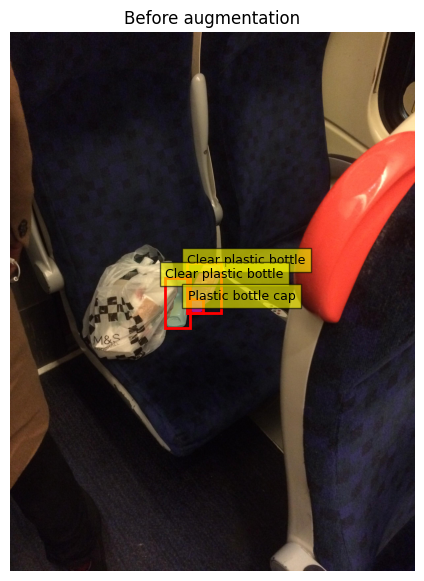

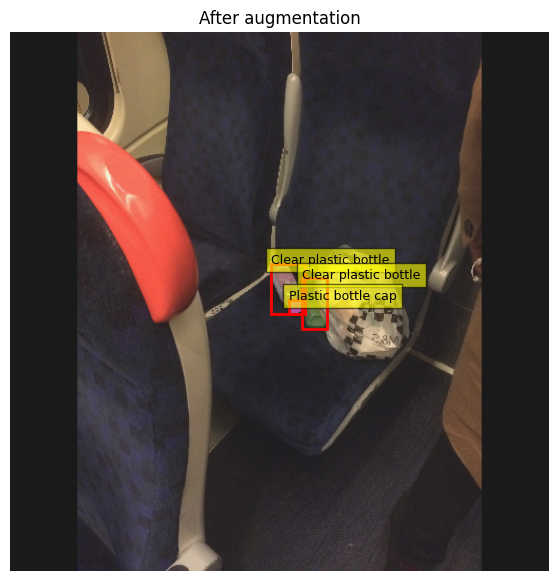

Image ID: 165


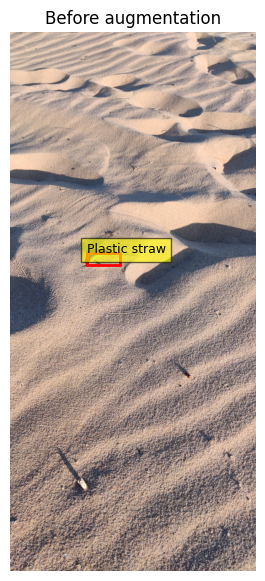

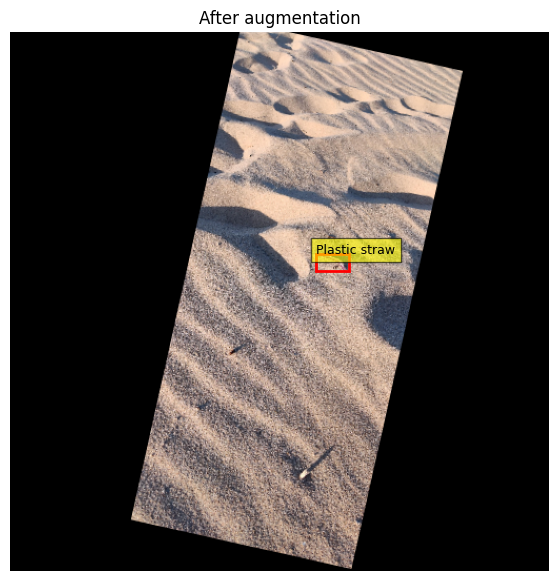

In [53]:
random.seed(SEED)

valid_image_ids = [
    image_id for image_id in coco_train_clean.imgs.keys()
    if len(coco_train_clean.getAnnIds(imgIds=image_id)) > 0
]

sample_ids = random.sample(valid_image_ids, 2)

for image_id in sample_ids:
    print(f"Image ID: {image_id}")
    show_before_after_augmentation(coco_train_clean, train_image_dir, image_id)

## 4.3 Exemple vizuale before / after

Cele doua perechi afisate mai sus arata efectul augmentarilor asupra imaginilor de train.

Se observa ca:
- imaginea este transformata vizual;
- bounding box-urile raman aliniate cu obiectele;
- mastile sunt transformate impreuna cu obiectele;
- label-urile raman corecte.

In plus, codul verifica explicit ca numarul de bounding boxes, masti si label-uri ramane acelasi inainte si dupa transformare. Aceasta verificare este importanta pentru instance segmentation, unde fiecare instanta trebuie sa pastreze perechea corecta intre clasa, box si masca.


## 4.4 Concluzie

Am folosit augmentari relevante pentru task-ul ales:
- HorizontalFlip;
- RandomBrightnessContrast;
- Affine pentru shift, scale si rotate;
- resize cu pastrarea raportului de aspect prin LongestMaxSize si PadIfNeeded.

Aceste augmentari sunt aplicate doar pe setul de train si sunt compatibile cu bounding boxes si masks. Seturile validation si test folosesc doar transformari deterministe, fara augmentari random, pentru a evalua modelul corect.


# 5. Model & Arhitectura

In aceasta sectiune definim modelul folosit pentru task-ul de instance segmentation.

Pentru proiect folosim **Mask R-CNN cu backbone ResNet-50 + FPN**, implementat in `torchvision`.

Alegerea este potrivita deoarece:
- task-ul nostru nu este doar clasificare, ci instance segmentation;
- modelul trebuie sa prezica pentru fiecare obiect:
  - clasa;
  - bounding box;
  - masca de segmentare;
- backbone-ul ResNet-50 este un CNN puternic, pre-antrenat pe ImageNet;
- FPN ajuta la detectarea obiectelor la scari diferite;
- modelul este compatibil cu PyTorch si cu formatul COCO folosit in dataset.

Vom modifica head-urile modelului astfel incat numarul de clase sa corespunda dataset-ului curatat.

In [54]:
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
Device: cuda


## 5.1 Pregatirea dataset-ului pentru Mask R-CNN

Modelul `Mask R-CNN` din `torchvision` asteapta datele in urmatorul format:

- imaginea: tensor de forma `[3, H, W]`, cu valori in intervalul `[0, 1]`;
- target-ul: dictionar care contine:
  - `boxes`: tensor `[N, 4]` in format `[x_min, y_min, x_max, y_max]`;
  - `labels`: tensor `[N]` cu id-urile claselor;
  - `masks`: tensor `[N, H, W]` cu mastile obiectelor;
  - `image_id`: id-ul imaginii;
  - `area`: aria fiecarui bounding box;
  - `iscrowd`: camp necesar pentru compatibilitate COCO.

Transformarile definite anterior cu Albumentations sunt folosite aici pentru a aplica aceleasi modificari asupra imaginilor, box-urilor si mastilor.

In [55]:
class CocoInstanceSegmentationDataset(Dataset):
    """Dataset PyTorch pentru COCO instance segmentation."""

    def __init__(self, annotation_path, image_dir, transforms=None):
        self.coco = COCO(str(annotation_path))
        self.image_dir = Path(image_dir)
        self.transforms = transforms
        self.image_ids = sorted(list(self.coco.imgs.keys()))

    def __len__(self):
        return len(self.image_ids)

    def _load_image_and_annotations(self, image_id):
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = self.image_dir / image_info["file_name"]
        image = np.array(Image.open(image_path).convert("RGB"))
        image_h, image_w = image.shape[:2]

        bboxes, labels, masks = [], [], []
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=image_id)):
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            x_min, y_min = max(0, x), max(0, y)
            x_max, y_max = min(image_w, x + w), min(image_h, y + h)
            new_w, new_h = x_max - x_min, y_max - y_min
            if new_w <= 1 or new_h <= 1:
                continue
            mask = self.coco.annToMask(ann)
            if mask.shape[:2] != (image_h, image_w):
                mask = cv2.resize(mask.astype(np.uint8), (image_w, image_h), interpolation=cv2.INTER_NEAREST)
            if mask.sum() == 0:
                continue
            bboxes.append([x_min, y_min, new_w, new_h])
            labels.append(ann["category_id"])
            masks.append(mask)
        return image, bboxes, labels, masks

    @staticmethod
    def _boxes_coco_to_xyxy(bboxes):
        return [[x, y, x + w, y + h] for x, y, w, h in bboxes]

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image, bboxes, labels, masks = self._load_image_and_annotations(image_id)

        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=bboxes, masks=masks, class_labels=labels)
            image = transformed["image"]
            bboxes = transformed["bboxes"]
            masks = transformed["masks"]
            labels = transformed["class_labels"]

        boxes_xyxy = self._boxes_coco_to_xyxy(bboxes)
        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32) if boxes_xyxy else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(np.stack(masks), dtype=torch.uint8) if len(masks) > 0 else torch.zeros((0, image.shape[1], image.shape[2]), dtype=torch.uint8)

        if len(boxes) > 0:
            area = (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (boxes[:, 3] - boxes[:, 1]).clamp(min=0)
        else:
            area = torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([image_id]),
            "area": area,
            "iscrowd": iscrowd,
        }
        return image, target

In [56]:
def collate_fn(batch):
    """
    Functie necesara pentru detection/segmentation.
    Imaginile pot avea numar diferit de obiecte, deci nu pot fi stivuite direct.
    """
    return tuple(zip(*batch))


train_dataset = CocoInstanceSegmentationDataset(
    annotation_path=CLEAN_OUTPUT_DIR / "train_cleaned.coco.json",
    image_dir=DATASET_DIR / "train",
    transforms=train_augmentations
)

valid_dataset = CocoInstanceSegmentationDataset(
    annotation_path=CLEAN_OUTPUT_DIR / "valid_cleaned.coco.json",
    image_dir=DATASET_DIR / "valid",
    transforms=eval_transforms
)

test_dataset = CocoInstanceSegmentationDataset(
    annotation_path=CLEAN_OUTPUT_DIR / "test_cleaned.coco.json",
    image_dir=DATASET_DIR / "test",
    transforms=eval_transforms
)

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))
print("Test samples:", len(test_dataset))
print("Batch size:", BATCH_SIZE)

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Train samples: 782
Validation samples: 225
Test samples: 116
Batch size: 2


In [57]:
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Image shape:", images[0].shape)
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels shape:", targets[0]["labels"].shape)
print("Masks shape:", targets[0]["masks"].shape)

print("Image dtype:", images[0].dtype)
print("Boxes dtype:", targets[0]["boxes"].dtype)
print("Labels dtype:", targets[0]["labels"].dtype)
print("Masks dtype:", targets[0]["masks"].dtype)

Number of images in batch: 2
Image shape: torch.Size([3, 512, 512])
Boxes shape: torch.Size([3, 4])
Labels shape: torch.Size([3])
Masks shape: torch.Size([3, 512, 512])
Image dtype: torch.float32
Boxes dtype: torch.float32
Labels dtype: torch.int64
Masks dtype: torch.uint8


## 5.2 Alegerea backbone-ului CNN

Backbone-ul ales este **ResNet-50**, folosit in interiorul arhitecturii Mask R-CNN.

ResNet-50 este potrivit pentru acest proiect deoarece:
- este un CNN adanc, capabil sa extraga trasaturi vizuale complexe;
- foloseste skip connections, ceea ce face antrenarea mai stabila;
- are ponderi pre-antrenate disponibile in PyTorch;
- este suficient de puternic pentru obiecte reale, dar inca fezabil pe Google Colab T4 cu batch size mic.

Modelul foloseste si **FPN**. FPN combina feature maps la mai multe rezolutii, ceea ce ajuta la detectarea obiectelor mici, medii si mari.

In [58]:
def get_mask_rcnn_model(num_classes):
    """
    Creeaza un model Mask R-CNN pre-antrenat si modifica head-urile pentru dataset-ul curent.

    num_classes include si clasa background.
    Exemplu:
    - 10 clase foreground + 1 background = 11 clase totale.
    """

    weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT

    model = maskrcnn_resnet50_fpn(weights=weights)

    # Inlocuim classification head-ul pentru numarul nostru de clase.
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_channels=in_features_box,
        num_classes=num_classes
    )

    # Inlocuim mask head-ul pentru numarul nostru de clase.
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_channels=in_features_mask,
        dim_reduced=hidden_layer,
        num_classes=num_classes
    )

    return model

In [59]:
NUM_CLASSES = len(clean_categories) + 1  # +1 pentru background

model = get_mask_rcnn_model(num_classes=NUM_CLASSES)
model = model.to(device)

print("Number of foreground classes:", len(clean_categories))
print("Number of classes including background:", NUM_CLASSES)
print("Model created successfully.")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 117MB/s]


Number of foreground classes: 10
Number of classes including background: 11
Model created successfully.


In [60]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "frozen_params": total_params - trainable_params
    }


param_info = count_parameters(model)

param_df = pd.DataFrame([
    {
        "Metric": "Total parameters",
        "Value": param_info["total_params"]
    },
    {
        "Metric": "Trainable parameters",
        "Value": param_info["trainable_params"]
    },
    {
        "Metric": "Frozen parameters",
        "Value": param_info["frozen_params"]
    }
])

param_df

,Metric,Value
0,Total parameters,43970833
1,Trainable parameters,43748433
2,Frozen parameters,222400


In [61]:
architecture_summary = {
    "model": "Mask R-CNN",
    "backbone": "ResNet-50 + FPN",
    "pretrained_weights": "COCO / torchvision default weights",
    "task": "Instance Segmentation",
    "num_foreground_classes": len(clean_categories),
    "num_classes_including_background": NUM_CLASSES,
    "modified_box_predictor": str(model.roi_heads.box_predictor),
    "modified_mask_predictor": str(model.roi_heads.mask_predictor),
}

architecture_summary

{'model': 'Mask R-CNN',
 'backbone': 'ResNet-50 + FPN',
 'pretrained_weights': 'COCO / torchvision default weights',
 'task': 'Instance Segmentation',
 'num_foreground_classes': 10,
 'num_classes_including_background': 11,
 'modified_box_predictor': 'FastRCNNPredictor(\n  (cls_score): Linear(in_features=1024, out_features=11, bias=True)\n  (bbox_pred): Linear(in_features=1024, out_features=44, bias=True)\n)',
 'modified_mask_predictor': 'MaskRCNNPredictor(\n  (conv5_mask): ConvTranspose2d(256, 256, kernel_size=(2, 2), stride=(2, 2))\n  (relu): ReLU(inplace=True)\n  (mask_fcn_logits): Conv2d(256, 11, kernel_size=(1, 1), stride=(1, 1))\n)'}

## 5.3 Modificarea head-urilor modelului

Modelul Mask R-CNN pre-antrenat initial este construit pentru un alt set de clase. Din acest motiv, head-urile finale trebuie inlocuite.

Am modificat doua componente:

1. **Box predictor**
   - prezice clasa fiecarui obiect;
   - prezice coordonatele bounding box-ului;
   - a fost adaptat la `NUM_CLASSES`, unde clasa 0 este background.

2. **Mask predictor**
   - prezice masca de segmentare pentru fiecare obiect detectat;
   - a fost adaptat la acelasi numar de clase.

Backbone-ul ResNet-50 + FPN ramane acelasi, deoarece are deja trasaturi vizuale utile invatate prin pre-antrenare.

In [62]:
model.train()

images, targets = next(iter(train_loader))

images = [image.to(device) for image in images]

targets = [
    {
        key: value.to(device)
        for key, value in target.items()
    }
    for target in targets
]

with torch.no_grad():
    loss_dict = model(images, targets)

print("Loss keys returned by the model:")
for key, value in loss_dict.items():
    print(f"{key}: {value.item():.4f}")

total_loss = sum(loss for loss in loss_dict.values())
print("Total loss:", round(total_loss.item(), 4))

Loss keys returned by the model:
loss_classifier: 2.4582
loss_box_reg: 0.1233
loss_mask: 1.1811
loss_objectness: 0.0339
loss_rpn_box_reg: 0.0055
Total loss: 3.8021


## 5.4 Explicarea arhitecturii

Arhitectura folosita este Mask R-CNN cu backbone ResNet-50 + FPN.

Fluxul modelului este urmatorul:

1. **Imaginea de intrare**
   - imaginea este convertita in tensor si trimisa catre model.

2. **Backbone ResNet-50**
   - extrage trasaturi vizuale din imagine;
   - primele straturi detecteaza muchii, texturi si forme simple;
   - straturile mai adanci extrag reprezentari mai complexe, utile pentru recunoasterea obiectelor.

3. **FPN**
   - construieste feature maps la mai multe scari;
   - ajuta modelul sa detecteze atat obiecte mari, cat si obiecte mici.

4. **Region Proposal Network**
   - propune regiuni candidate unde ar putea exista obiecte.

5. **Box head**
   - clasifica fiecare regiune propusa;
   - ajusteaza bounding box-ul pentru fiecare obiect.

6. **Mask head**
   - produce o masca pentru fiecare obiect detectat;
   - aceasta masca estimeaza pixelii care apartin instantei respective.

Loss-ul total al modelului este o combinatie de mai multe componente:
- loss de clasificare;
- loss pentru regresia bounding box-urilor;
- loss pentru propunerile RPN;
- loss pentru mastile de segmentare.

Astfel, modelul invata simultan unde sunt obiectele, ce clasa au si ce forma are fiecare instanta.

## 5.5 Concluzie Model & Arhitectura

In aceasta sectiune am ales si definit modelul principal al proiectului.

Am indeplinit cerintele sectiunii 5 astfel:
- am ales un backbone CNN: ResNet-50;
- am folosit ponderi pre-antrenate disponibile in PyTorch;
- am ales o arhitectura potrivita pentru instance segmentation: Mask R-CNN cu FPN;
- am modificat head-urile de clasificare si segmentare pentru numarul de clase din dataset-ul curatat;
- am verificat ca modelul primeste corect batch-uri din dataset;
- am rulat un forward pass de test si am obtinut componentele de loss.

Aceasta arhitectura va fi folosita in sectiunile urmatoare pentru fine-tuning, adaugarea unui head suplimentar si evaluarea experimentala.

# 6. Fine-tuning

In aceasta sectiune adaptam modelul pre-antrenat la dataset-ul curatat, fara antrenare de la zero.

Cerintele acoperite aici sunt:
- model pre-antrenat cu head-uri adaptate la numarul corect de clase;
- backbone inghetat in primele epoci;
- dezghetare progresiva pentru fine-tuning complet;
- loss, optimizer si scheduler alese explicit;
- checkpoint-uri, loguri si curbe train/validation loss.

In [63]:
# Configurare fine-tuning
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model = get_mask_rcnn_model(num_classes=NUM_CLASSES).to(device)

TOTAL_FINE_TUNING_EPOCHS = int(CONFIG.get("num_epochs", 5))
FROZEN_BACKBONE_EPOCHS = 2
UNFROZEN_BACKBONE_EPOCHS = max(1, TOTAL_FINE_TUNING_EPOCHS - FROZEN_BACKBONE_EPOCHS)
FINE_TUNING_LR_HEADS = 1e-4
FINE_TUNING_LR_ALL = 5e-5
FINE_TUNING_WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0
MAX_TRAIN_BATCHES_PER_EPOCH = None
MAX_VALID_BATCHES_PER_EPOCH = None

BEST_MODEL_PATH = MODELS_DIR / "maskrcnn_resnet50_fpn_finetuned_best.pth"
LAST_MODEL_PATH = MODELS_DIR / "maskrcnn_resnet50_fpn_finetuned_last.pth"
TRAINING_HISTORY_PATH = LOGS_DIR / "fine_tuning_history.csv"
FINE_TUNING_FIGURE_PATH = FIGURES_DIR / "section6_fine_tuning_loss_curves.png"

# Date ssalvate deja in drive de la prima antrenare.
RUN_FINE_TUNING = not (BEST_MODEL_PATH.exists() and TRAINING_HISTORY_PATH.exists())
RESUME_FINE_TUNING = BEST_MODEL_PATH.exists() and RUN_FINE_TUNING

fine_tuning_config = {
    "epochs_total": TOTAL_FINE_TUNING_EPOCHS,
    "epochs_frozen_backbone": FROZEN_BACKBONE_EPOCHS,
    "epochs_unfrozen_backbone": UNFROZEN_BACKBONE_EPOCHS,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "lr_heads": FINE_TUNING_LR_HEADS,
    "lr_all_layers": FINE_TUNING_LR_ALL,
    "weight_decay": FINE_TUNING_WEIGHT_DECAY,
    "loss": "torchvision Mask R-CNN loss: classifier + box + mask + objectness + rpn_box",
    "run_fine_tuning_now": RUN_FINE_TUNING,
    "best_model_path": str(BEST_MODEL_PATH),
}
fine_tuning_config

{'epochs_total': 5,
 'epochs_frozen_backbone': 2,
 'epochs_unfrozen_backbone': 3,
 'optimizer': 'AdamW',
 'scheduler': 'CosineAnnealingLR',
 'lr_heads': 0.0001,
 'lr_all_layers': 5e-05,
 'weight_decay': 0.0001,
 'loss': 'torchvision Mask R-CNN loss: classifier + box + mask + objectness + rpn_box',
 'run_fine_tuning_now': False,
 'best_model_path': '/content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_finetuned_best.pth'}

## 6.1 Strategie freeze / unfreeze

Folosim doua etape. In prima etapa, backbone-ul ResNet-50 + FPN ramane inghetat si se adapteaza head-urile noi la clasele dataset-ului. In etapa a doua, backbone-ul este dezghetat si invata gradual trasaturi specifice domeniului TACO Trash.

Loss-ul este cel standard din Mask R-CNN: clasificare, regresie bounding box, objectness/RPN, regresie RPN si masca. `AdamW` este stabil pentru fine-tuning, iar `CosineAnnealingLR` reduce treptat learning rate-ul.

In [64]:
def set_backbone_trainable(mask_rcnn_model, trainable):
    for parameter in mask_rcnn_model.backbone.parameters():
        parameter.requires_grad = trainable


def count_trainable_parameters_by_block(mask_rcnn_model):
    rows = []
    for name, module in {
        "backbone": mask_rcnn_model.backbone,
        "rpn": mask_rcnn_model.rpn,
        "roi_heads": mask_rcnn_model.roi_heads,
    }.items():
        total = sum(p.numel() for p in module.parameters())
        trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append({"block": name, "total_params": total, "trainable_params": trainable, "frozen_params": total - trainable})
    return pd.DataFrame(rows)


def move_batch_to_device(images, targets, device):
    images = [image.to(device) for image in images]
    targets = [{key: value.to(device) for key, value in target.items()} for target in targets]
    return images, targets


def average_losses(loss_meter, num_batches):
    return {key: value / max(1, num_batches) for key, value in loss_meter.items()}


def train_one_epoch(model, data_loader, optimizer, device, epoch, max_batches=None, grad_clip_norm=None):
    model.train()
    loss_meter = defaultdict(float)
    num_batches = 0
    start_time = time.time()

    for batch_idx, (images, targets) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, targets = move_batch_to_device(images, targets, device)
        optimizer.zero_grad(set_to_none=True)
        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(total_loss):
            raise RuntimeError(f"Non-finite loss at epoch {epoch}, batch {batch_idx}: {total_loss.item()}")

        total_loss.backward()
        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        optimizer.step()

        for key, value in loss_dict.items():
            loss_meter[key] += float(value.detach().cpu())
        loss_meter["total_loss"] += float(total_loss.detach().cpu())
        num_batches += 1

        if (batch_idx + 1) % 25 == 0:
            print(f"Epoch {epoch} | batch {batch_idx + 1}/{len(data_loader)} | loss={float(total_loss.detach().cpu()):.4f}")

    result = average_losses(loss_meter, num_batches)
    result["batches"] = num_batches
    result["seconds"] = time.time() - start_time
    return result


@torch.no_grad()
def compute_validation_loss(model, data_loader, device, max_batches=None):
    # Torchvision detection models returneaza loss doar in train mode.
    previous_mode = model.training
    model.train()
    loss_meter = defaultdict(float)
    num_batches = 0

    for batch_idx, (images, targets) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images, targets = move_batch_to_device(images, targets, device)
        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        for key, value in loss_dict.items():
            loss_meter[key] += float(value.detach().cpu())
        loss_meter["total_loss"] += float(total_loss.detach().cpu())
        num_batches += 1

    model.train(previous_mode)
    result = average_losses(loss_meter, num_batches)
    result["batches"] = num_batches
    return result


set_backbone_trainable(model, trainable=False)
count_trainable_parameters_by_block(model)

,block,total_params,trainable_params,frozen_params
0,backbone,26799296,0,26799296
1,rpn,593935,593935,0
2,roi_heads,16577602,16577602,0


In [65]:
fine_tuning_history = []
best_valid_loss = float("inf")
global_epoch = 0

if RESUME_FINE_TUNING and BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    best_valid_loss = checkpoint.get("best_valid_loss", best_valid_loss)
    print("Resumed checkpoint:", BEST_MODEL_PATH)

training_stages = [
    {"stage": "frozen_backbone", "epochs": FROZEN_BACKBONE_EPOCHS, "train_backbone": False, "lr": FINE_TUNING_LR_HEADS},
    {"stage": "unfrozen_backbone", "epochs": UNFROZEN_BACKBONE_EPOCHS, "train_backbone": True, "lr": FINE_TUNING_LR_ALL},
]

if RUN_FINE_TUNING:
    for stage in training_stages:
        set_backbone_trainable(model, stage["train_backbone"])
        optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=stage["lr"], weight_decay=FINE_TUNING_WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=max(1, stage["epochs"]), eta_min=stage["lr"] * 0.1)

        print()
        print(f"Stage: {stage['stage']}")
        display(count_trainable_parameters_by_block(model))

        for _ in range(stage["epochs"]):
            global_epoch += 1
            train_losses = train_one_epoch(model, train_loader, optimizer, device, global_epoch, MAX_TRAIN_BATCHES_PER_EPOCH, GRAD_CLIP_NORM)
            valid_losses = compute_validation_loss(model, valid_loader, device, MAX_VALID_BATCHES_PER_EPOCH)
            scheduler.step()

            row = {
                "epoch": global_epoch,
                "stage": stage["stage"],
                "learning_rate": scheduler.get_last_lr()[0],
                "train_loss": train_losses["total_loss"],
                "valid_loss": valid_losses["total_loss"],
                "train_batches": train_losses["batches"],
                "valid_batches": valid_losses["batches"],
                "seconds": train_losses["seconds"],
            }
            for key, value in train_losses.items():
                if key not in ["total_loss", "batches", "seconds"]:
                    row[f"train_{key}"] = value
            for key, value in valid_losses.items():
                if key not in ["total_loss", "batches"]:
                    row[f"valid_{key}"] = value
            fine_tuning_history.append(row)

            checkpoint = {
                "epoch": global_epoch,
                "stage": stage["stage"],
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_valid_loss": best_valid_loss,
                "config": fine_tuning_config,
            }
            torch.save(checkpoint, LAST_MODEL_PATH)
            if valid_losses["total_loss"] < best_valid_loss:
                best_valid_loss = valid_losses["total_loss"]
                checkpoint["best_valid_loss"] = best_valid_loss
                torch.save(checkpoint, BEST_MODEL_PATH)
                print(f"Saved best model: valid_loss={best_valid_loss:.4f}")

            print(f"Epoch {global_epoch:02d} | {stage['stage']} | train={train_losses['total_loss']:.4f} | valid={valid_losses['total_loss']:.4f} | lr={scheduler.get_last_lr()[0]:.2e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    training_history_df = pd.DataFrame(fine_tuning_history)
    training_history_df.to_csv(TRAINING_HISTORY_PATH, index=False)
else:
    training_history_df = pd.read_csv(TRAINING_HISTORY_PATH) if TRAINING_HISTORY_PATH.exists() else pd.DataFrame()

training_history_df

,epoch,stage,learning_rate,train_loss,valid_loss,train_batches,valid_batches,seconds,train_loss_classifier,train_loss_box_reg,train_loss_mask,train_loss_objectness,train_loss_rpn_box_reg,valid_loss_classifier,valid_loss_box_reg,valid_loss_mask,valid_loss_objectness,valid_loss_rpn_box_reg
0,1,frozen_backbone,0.000055,0.983783,0.823011,391,113,240.626415,0.171486,0.098402,0.375153,0.237611,0.101132,0.138768,0.083677,0.311134,0.167680,0.121751
1,2,frozen_backbone,0.000010,0.782936,0.807657,391,113,239.473051,0.143050,0.086288,0.286037,0.175641,0.091919,0.137507,0.081168,0.288084,0.175767,0.125131
2,3,unfrozen_backbone,0.000039,0.801905,0.748677,391,113,410.123145,0.167938,0.093684,0.285689,0.163992,0.090602,0.158076,0.082618,0.279374,0.127826,0.100782
3,4,unfrozen_backbone,0.000016,0.707651,0.712705,391,113,433.801172,0.157190,0.092306,0.250724,0.128662,0.078769,0.138298,0.076365,0.272550,0.124944,0.100548
4,5,unfrozen_backbone,0.000005,0.633615,0.708553,391,113,437.700191,0.140510,0.089257,0.231460,0.104534,0.067854,0.136594,0.073464,0.269921,0.131794,0.096780


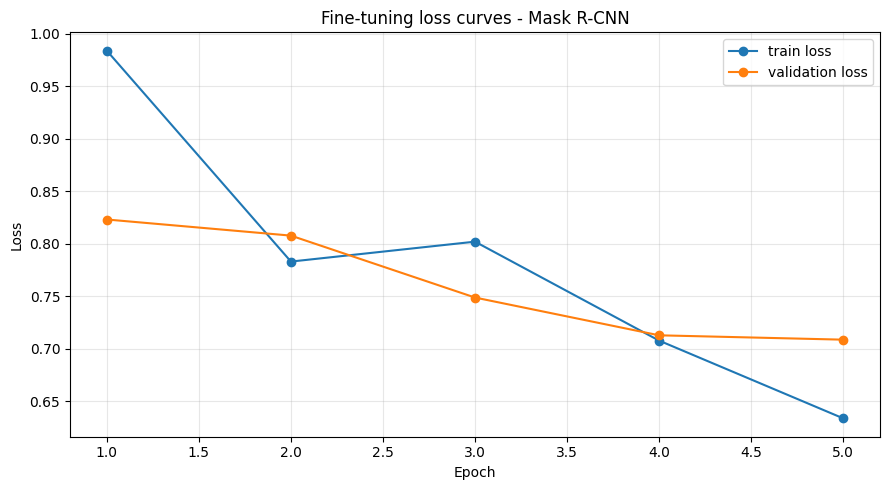

Saved: /content/drive/MyDrive/ProiectD3/outputs/figures/section6_fine_tuning_loss_curves.png


In [66]:
if len(training_history_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(training_history_df["epoch"], training_history_df["train_loss"], marker="o", label="train loss")
    plt.plot(training_history_df["epoch"], training_history_df["valid_loss"], marker="o", label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Fine-tuning loss curves - Mask R-CNN")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FINE_TUNING_FIGURE_PATH, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", FINE_TUNING_FIGURE_PATH)
else:
    print("No fine-tuning history available yet.")

- Train Loss = cat de mult greseste modelul pe imaginile vazute la antrenare.
- Validation Loss = cat de mult greseste modelul pe imagini nevazute in timpul antrenarii.

Curbele de loss arata ca fine-tuning-ul modelului Mask R-CNN este stabil. Train loss scade progresiv, ceea ce indica faptul ca modelul invata din datele de antrenare. Validation loss scade in primele epoci si apoi se stabilizeaza, sugerand ca modelul generalizeaza rezonabil pe date nevazute. Diferenta moderata dintre train loss si validation loss la final nu indica overfitting sever.

## 6.2 Justificari

- `AdamW` este ales pentru stabilitate la fine-tuning si weight decay decuplat.
- `1e-4` pentru head-uri permite adaptarea predictorilor noi.
- `5e-5` dupa unfreeze protejeaza backbone-ul pre-antrenat de update-uri prea mari.
- `weight_decay=1e-4` reduce overfitting-ul.
- `CosineAnnealingLR` scade lin learning rate-ul.
- Gradient clipping limiteaza spike-urile de loss, frecvente la detection/segmentation.

Sectiunea acopera freeze, unfreeze, loss, optimizer, scheduler si explicatiile cerute.

# 7. Adaugare Head Nou

Mask R-CNN are deja head-uri pentru clasificare, bounding box si masca. Pentru cerinta de multi-head adaugam un **auxiliary image-level classification head**.

Head-ul nou primeste feature maps din backbone si prezice un vector multi-label: ce clase apar in imagine, indiferent de numarul de instante. Astfel, el regularizeaza backbone-ul cu informatie globala, in timp ce head-urile Mask R-CNN lucreaza pe regiuni si instante.

Loss-ul total este:

`L_total = L_mask_rcnn + lambda_aux * L_aux_bce`

unde `L_aux_bce` este `BCEWithLogitsLoss`, iar `lambda_aux = 0.2`.

In [67]:
def build_multilabel_targets(targets, num_foreground_classes, device):
    multilabel = torch.zeros((len(targets), num_foreground_classes), dtype=torch.float32, device=device)
    for image_idx, target in enumerate(targets):
        labels = target["labels"].to(device)
        labels = labels[(labels > 0) & (labels <= num_foreground_classes)]
        if len(labels) > 0:
            multilabel[image_idx, labels - 1] = 1.0
    return multilabel


class MaskRCNNWithAuxiliaryClassifier(nn.Module):
    """Mask R-CNN + head auxiliar multi-label la nivel de imagine."""

    def __init__(self, base_model, num_foreground_classes, aux_loss_weight=0.2, dropout=0.2):
        super().__init__()
        self.base_model = base_model
        self.num_foreground_classes = num_foreground_classes
        self.aux_loss_weight = aux_loss_weight
        self._latest_features = None
        channels = getattr(self.base_model.backbone, "out_channels", 256)
        self.aux_classifier = nn.Sequential(
            nn.Linear(channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_foreground_classes),
        )
        self.aux_criterion = nn.BCEWithLogitsLoss()
        self._hook_handle = self.base_model.backbone.register_forward_hook(self._capture_features)

    def _capture_features(self, module, inputs, output):
        self._latest_features = output

    def _pool_features(self, features):
        maps = list(features.values()) if isinstance(features, dict) else [features]
        pooled = [F.adaptive_avg_pool2d(feature_map, 1).flatten(1) for feature_map in maps]
        return torch.stack(pooled, dim=0).mean(dim=0)

    def forward(self, images, targets=None):
        self._latest_features = None
        base_output = self.base_model(images, targets)
        if self._latest_features is None:
            raise RuntimeError("Nu am capturat feature maps din backbone.")
        aux_logits = self.aux_classifier(self._pool_features(self._latest_features))
        if self.training:
            if targets is None:
                raise ValueError("Targets are required during training.")
            aux_targets = build_multilabel_targets(targets, self.num_foreground_classes, aux_logits.device)
            loss_dict = dict(base_output)
            loss_dict["loss_aux_classification"] = self.aux_loss_weight * self.aux_criterion(aux_logits, aux_targets)
            return loss_dict
        return {"detections": base_output, "aux_logits": aux_logits, "aux_probs": torch.sigmoid(aux_logits)}


AUX_LOSS_WEIGHT = 0.2
AUX_DROPOUT = 0.2
MULTI_TASK_EPOCHS = 2
MULTI_TASK_LR = 5e-5

BEST_MULTI_TASK_MODEL_PATH = MODELS_DIR / "maskrcnn_resnet50_fpn_aux_head_best.pth"
LAST_MULTI_TASK_MODEL_PATH = MODELS_DIR / "maskrcnn_resnet50_fpn_aux_head_last.pth"
MULTI_TASK_HISTORY_PATH = LOGS_DIR / "multi_task_head_history.csv"
MULTI_TASK_FIGURE_PATH = FIGURES_DIR / "section7_multi_task_loss_curves.png"

RUN_MULTI_TASK_TRAINING = not (BEST_MULTI_TASK_MODEL_PATH.exists() and MULTI_TASK_HISTORY_PATH.exists())

multi_task_config = {
    "new_head": "auxiliary image-level multi-label classifier",
    "aux_loss": "BCEWithLogitsLoss",
    "aux_loss_weight": AUX_LOSS_WEIGHT,
    "epochs": MULTI_TASK_EPOCHS,
    "learning_rate": MULTI_TASK_LR,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "run_multi_task_training_now": RUN_MULTI_TASK_TRAINING,
    "best_model_path": str(BEST_MULTI_TASK_MODEL_PATH),
}
multi_task_config

{'new_head': 'auxiliary image-level multi-label classifier',
 'aux_loss': 'BCEWithLogitsLoss',
 'aux_loss_weight': 0.2,
 'epochs': 2,
 'learning_rate': 5e-05,
 'optimizer': 'AdamW',
 'scheduler': 'CosineAnnealingLR',
 'run_multi_task_training_now': False,
 'best_model_path': '/content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_aux_head_best.pth'}

In [68]:
# Construim modelul multi-task pornind de la checkpoint-ul fine-tuned, daca exista.
base_model_for_aux = get_mask_rcnn_model(num_classes=NUM_CLASSES).to(device)

if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    base_model_for_aux.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded fine-tuned checkpoint:", BEST_MODEL_PATH)
else:
    print("Fine-tuned checkpoint not found. Starting auxiliary model from pretrained adapted heads.")

multi_task_model = MaskRCNNWithAuxiliaryClassifier(
    base_model=base_model_for_aux,
    num_foreground_classes=len(clean_categories),
    aux_loss_weight=AUX_LOSS_WEIGHT,
    dropout=AUX_DROPOUT,
).to(device)

set_backbone_trainable(multi_task_model.base_model, trainable=True)

print("Multi-task model ready.")
print(multi_task_model.aux_classifier)
display(count_trainable_parameters_by_block(multi_task_model.base_model))

Loaded fine-tuned checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_finetuned_best.pth
Multi-task model ready.
Sequential(
  (0): Linear(in_features=256, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)


,block,total_params,trainable_params,frozen_params
0,backbone,26799296,26799296,0
1,rpn,593935,593935,0
2,roi_heads,16577602,16577602,0


In [69]:
multi_task_history = []
best_multi_task_valid_loss = float("inf")

if RUN_MULTI_TASK_TRAINING:
    optimizer = optim.AdamW([p for p in multi_task_model.parameters() if p.requires_grad], lr=MULTI_TASK_LR, weight_decay=FINE_TUNING_WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=max(1, MULTI_TASK_EPOCHS), eta_min=MULTI_TASK_LR * 0.1)

    for epoch in range(1, MULTI_TASK_EPOCHS + 1):
        train_losses = train_one_epoch(multi_task_model, train_loader, optimizer, device, epoch, MAX_TRAIN_BATCHES_PER_EPOCH, GRAD_CLIP_NORM)
        valid_losses = compute_validation_loss(multi_task_model, valid_loader, device, MAX_VALID_BATCHES_PER_EPOCH)
        scheduler.step()

        row = {
            "epoch": epoch,
            "learning_rate": scheduler.get_last_lr()[0],
            "train_loss": train_losses["total_loss"],
            "valid_loss": valid_losses["total_loss"],
            "train_aux_loss": train_losses.get("loss_aux_classification", np.nan),
            "valid_aux_loss": valid_losses.get("loss_aux_classification", np.nan),
            "train_batches": train_losses["batches"],
            "valid_batches": valid_losses["batches"],
            "seconds": train_losses["seconds"],
        }
        multi_task_history.append(row)

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": multi_task_model.state_dict(),
            "base_model_state_dict": multi_task_model.base_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_valid_loss": best_multi_task_valid_loss,
            "config": multi_task_config,
        }
        torch.save(checkpoint, LAST_MULTI_TASK_MODEL_PATH)
        if valid_losses["total_loss"] < best_multi_task_valid_loss:
            best_multi_task_valid_loss = valid_losses["total_loss"]
            checkpoint["best_valid_loss"] = best_multi_task_valid_loss
            torch.save(checkpoint, BEST_MULTI_TASK_MODEL_PATH)
            print(f"Saved best multi-task model: valid_loss={best_multi_task_valid_loss:.4f}")

        print(f"Multi-task epoch {epoch:02d} | train={train_losses['total_loss']:.4f} | valid={valid_losses['total_loss']:.4f} | aux_valid={valid_losses.get('loss_aux_classification', 0):.4f}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    multi_task_history_df = pd.DataFrame(multi_task_history)
    multi_task_history_df.to_csv(MULTI_TASK_HISTORY_PATH, index=False)
else:
    multi_task_history_df = pd.read_csv(MULTI_TASK_HISTORY_PATH) if MULTI_TASK_HISTORY_PATH.exists() else pd.DataFrame()

multi_task_history_df

,epoch,learning_rate,train_loss,valid_loss,train_aux_loss,valid_aux_loss,train_batches,valid_batches,seconds
0,1,0.000028,0.764207,0.824051,0.095387,0.086166,391,113,457.200430
1,2,0.000005,0.702953,0.781212,0.085987,0.085990,391,113,440.932171


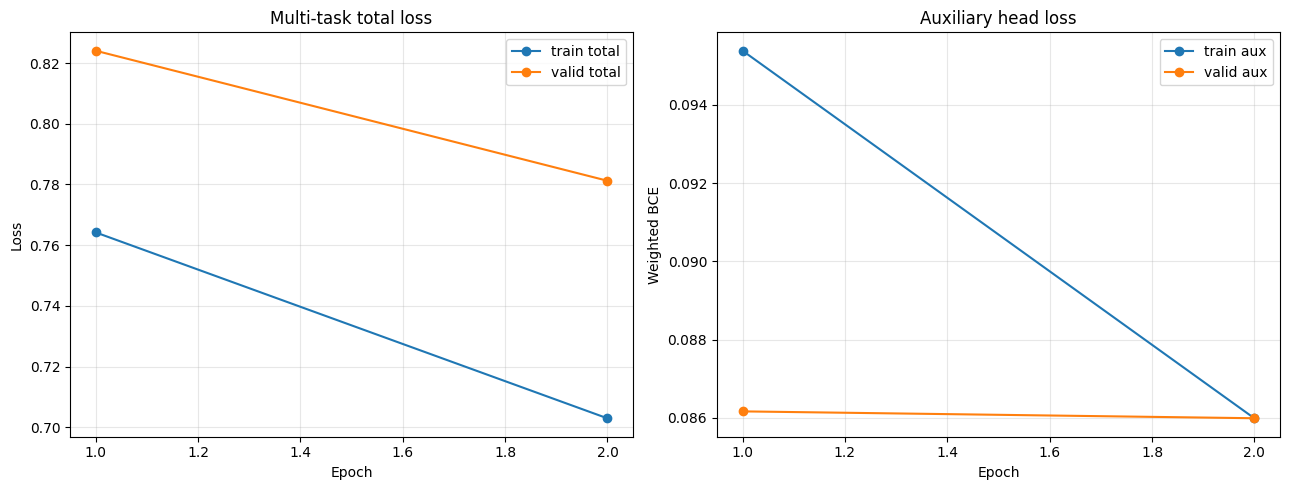

Saved: /content/drive/MyDrive/ProiectD3/outputs/figures/section7_multi_task_loss_curves.png


In [70]:
if len(multi_task_history_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(multi_task_history_df["epoch"], multi_task_history_df["train_loss"], marker="o", label="train total")
    axes[0].plot(multi_task_history_df["epoch"], multi_task_history_df["valid_loss"], marker="o", label="valid total")
    axes[0].set_title("Multi-task total loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(multi_task_history_df["epoch"], multi_task_history_df["train_aux_loss"], marker="o", label="train aux")
    axes[1].plot(multi_task_history_df["epoch"], multi_task_history_df["valid_aux_loss"], marker="o", label="valid aux")
    axes[1].set_title("Auxiliary head loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Weighted BCE")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(MULTI_TASK_FIGURE_PATH, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", MULTI_TASK_FIGURE_PATH)
else:
    print("No multi-task history available yet.")

Graficul prezinta evolutia modelului multi-task, in care Mask R-CNN este completat cu un head auxiliar de clasificare la nivel de imagine. Loss-ul total scade atat pe train, cat si pe validation, ceea ce indica o antrenare stabila si faptul ca adaugarea head-ului auxiliar nu destabilizeaza modelul principal.

Loss-ul auxiliar are valori mici si ramane aproape constant pe validation. Acest lucru sugereaza ca head-ul auxiliar invata un semnal global despre clasele prezente in imagine, dar contributia sa este limitata in cele doua epoci rulate. Din acest motiv, rezultatul trebuie interpretat ca o validare de concept pentru abordarea multi-task, nu ca o imbunatatire majora garantata fata de Mask R-CNN simplu.

## 7.1 Diferenta dintre head-uri

- Head-ul de clasificare/bbox din Mask R-CNN estimeaza clasa si coordonatele pentru fiecare regiune propusa.
- Mask head-ul estimeaza masca binara pentru fiecare instanta detectata.
- Head-ul auxiliar adaugat estimeaza clasele prezente la nivel de imagine, ca vector multi-label.

La antrenare, loss-ul auxiliar este combinat cu loss-ul Mask R-CNN prin `lambda_aux = 0.2`. La inferenta, folosim in continuare bbox-urile, scorurile si mastile ca rezultate principale, iar probabilitatile auxiliare ofera context global despre clasele posibile.

# 8. Experimente & Evaluare

Evaluam pe setul de test si comparam trei variante:

1. **Baseline adapted pretrained**: backbone pre-antrenat, head-uri adaptate, fara fine-tuning pe dataset.
2. **Fine-tuned Mask R-CNN**: modelul rezultat din sectiunea 6.
3. **Mask R-CNN + auxiliary head**: modelul multi-task din sectiunea 7.

Metricile sunt potrivite pentru instance segmentation: precision/recall/F1 la IoU 0.50, mean box IoU si mean mask IoU pentru predictiile potrivite. Curbele train/validation loss sunt plotate si salvate.

In [71]:
SCORE_THRESHOLD = float(CONFIG.get("score_threshold", 0.5))
MASK_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
EVAL_MAX_BATCHES = None

EXPERIMENT_RESULTS_PATH = LOGS_DIR / "section8_experiment_results.csv"
EXPERIMENT_CURVES_PATH = FIGURES_DIR / "section8_train_valid_loss_curves.png"


def unpack_detections(model_output):
    if isinstance(model_output, dict) and "detections" in model_output:
        return model_output["detections"]
    return model_output


def compute_mask_iou_matrix(pred_masks, gt_masks):
    if pred_masks.numel() == 0 or gt_masks.numel() == 0:
        return torch.zeros((pred_masks.shape[0], gt_masks.shape[0]), dtype=torch.float32)
    pred_flat = pred_masks.reshape(pred_masks.shape[0], -1).bool()
    gt_flat = gt_masks.reshape(gt_masks.shape[0], -1).bool()
    inter = (pred_flat[:, None, :] & gt_flat[None, :, :]).sum(dim=-1).float()
    union = (pred_flat[:, None, :] | gt_flat[None, :, :]).sum(dim=-1).float()
    return inter / union.clamp(min=1.0)


def compute_single_image_metrics(prediction, target, score_threshold=0.5, mask_threshold=0.5, iou_threshold=0.5):
    gt_boxes = target["boxes"].detach().cpu()
    gt_labels = target["labels"].detach().cpu()
    gt_masks = target["masks"].detach().cpu().bool()

    pred_boxes = prediction.get("boxes", torch.empty((0, 4))).detach().cpu()
    pred_labels = prediction.get("labels", torch.empty((0,), dtype=torch.int64)).detach().cpu()
    pred_scores = prediction.get("scores", torch.ones((len(pred_boxes),))).detach().cpu()

    keep = pred_scores >= score_threshold
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_scores = pred_scores[keep]

    if "masks" in prediction and prediction["masks"] is not None:
        pred_masks = prediction["masks"].detach().cpu()[keep, 0] >= mask_threshold
    else:
        h, w = gt_masks.shape[-2:] if gt_masks.numel() > 0 else (IMAGE_SIZE, IMAGE_SIZE)
        pred_masks = torch.zeros((len(pred_boxes), h, w), dtype=torch.bool)

    num_gt, num_pred = len(gt_boxes), len(pred_boxes)
    if num_gt == 0 and num_pred == 0:
        return {"tp":0,"fp":0,"fn":0,"precision":1.0,"recall":1.0,"f1":1.0,"matched_count":0,"sum_box_iou":0.0,"sum_mask_iou":0.0,"mean_box_iou_matched":0.0,"mean_mask_iou_matched":0.0,"num_gt":0,"num_predictions":0}
    if num_gt == 0:
        return {"tp":0,"fp":num_pred,"fn":0,"precision":0.0,"recall":1.0,"f1":0.0,"matched_count":0,"sum_box_iou":0.0,"sum_mask_iou":0.0,"mean_box_iou_matched":0.0,"mean_mask_iou_matched":0.0,"num_gt":0,"num_predictions":num_pred}
    if num_pred == 0:
        return {"tp":0,"fp":0,"fn":num_gt,"precision":0.0,"recall":0.0,"f1":0.0,"matched_count":0,"sum_box_iou":0.0,"sum_mask_iou":0.0,"mean_box_iou_matched":0.0,"mean_mask_iou_matched":0.0,"num_gt":num_gt,"num_predictions":0}

    box_ious = torchvision.ops.box_iou(pred_boxes, gt_boxes)
    mask_ious = compute_mask_iou_matrix(pred_masks, gt_masks)
    used_predictions = set()
    matched_box_ious, matched_mask_ious = [], []

    for gt_idx in range(num_gt):
        candidates = [p for p in range(num_pred) if p not in used_predictions and pred_labels[p] == gt_labels[gt_idx]]
        if not candidates:
            continue
        best_pred = max(candidates, key=lambda p: float(mask_ious[p, gt_idx]))
        best_mask_iou = float(mask_ious[best_pred, gt_idx])
        if best_mask_iou >= iou_threshold:
            used_predictions.add(best_pred)
            matched_mask_ious.append(best_mask_iou)
            matched_box_ious.append(float(box_ious[best_pred, gt_idx]))

    tp = len(used_predictions)
    fp = num_pred - tp
    fn = num_gt - tp
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    sum_box_iou = float(np.sum(matched_box_ious)) if matched_box_ious else 0.0
    sum_mask_iou = float(np.sum(matched_mask_ious)) if matched_mask_ious else 0.0

    return {
        "tp":tp,"fp":fp,"fn":fn,"precision":precision,"recall":recall,"f1":f1,
        "matched_count":tp,"sum_box_iou":sum_box_iou,"sum_mask_iou":sum_mask_iou,
        "mean_box_iou_matched":sum_box_iou / tp if tp else 0.0,
        "mean_mask_iou_matched":sum_mask_iou / tp if tp else 0.0,
        "num_gt":num_gt,"num_predictions":num_pred,
    }


@torch.no_grad()
def evaluate_instance_segmentation_model(model, data_loader, device, model_name, max_batches=None, score_threshold=0.5):
    model.eval()
    records = []
    dataset_index = 0
    for batch_idx, (images, targets) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        outputs = unpack_detections(model([image.to(device) for image in images]))
        for local_idx, prediction in enumerate(outputs):
            metrics = compute_single_image_metrics(prediction, targets[local_idx], score_threshold, MASK_THRESHOLD, IOU_THRESHOLD)
            image_id_tensor = targets[local_idx]["image_id"].detach().cpu().flatten()
            metrics.update({"model": model_name, "dataset_index": dataset_index, "image_id": int(image_id_tensor[0])})
            records.append(metrics)
            dataset_index += 1

    per_image_df = pd.DataFrame(records)
    tp = int(per_image_df["tp"].sum()) if len(per_image_df) else 0
    fp = int(per_image_df["fp"].sum()) if len(per_image_df) else 0
    fn = int(per_image_df["fn"].sum()) if len(per_image_df) else 0
    matched = int(per_image_df["matched_count"].sum()) if len(per_image_df) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    summary = {
        "model": model_name, "split": "test", "score_threshold": score_threshold, "iou_threshold": IOU_THRESHOLD,
        "test_images_evaluated": len(per_image_df), "tp": tp, "fp": fp, "fn": fn,
        "precision@0.50": precision, "recall@0.50": recall, "f1@0.50": f1,
        "mean_box_iou_matched": per_image_df["sum_box_iou"].sum() / matched if matched else 0.0,
        "mean_mask_iou_matched": per_image_df["sum_mask_iou"].sum() / matched if matched else 0.0,
    }
    return summary, per_image_df

print("Evaluation helpers ready.")

Evaluation helpers ready.


In [72]:
def build_baseline_model_for_eval():
    model_eval = get_mask_rcnn_model(num_classes=NUM_CLASSES).to(device)
    model_eval.eval()
    return model_eval


def build_finetuned_model_for_eval():
    model_eval = get_mask_rcnn_model(num_classes=NUM_CLASSES).to(device)
    if BEST_MODEL_PATH.exists():
        checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
        model_eval.load_state_dict(checkpoint["model_state_dict"])
        print("Loaded fine-tuned checkpoint:", BEST_MODEL_PATH)
    else:
        print("Fine-tuned checkpoint missing. Evaluating current adapted model.")
    model_eval.eval()
    return model_eval


def build_multi_task_model_for_eval():
    base_model = get_mask_rcnn_model(num_classes=NUM_CLASSES).to(device)
    model_eval = MaskRCNNWithAuxiliaryClassifier(base_model, len(clean_categories), AUX_LOSS_WEIGHT, AUX_DROPOUT).to(device)
    if BEST_MULTI_TASK_MODEL_PATH.exists():
        checkpoint = torch.load(BEST_MULTI_TASK_MODEL_PATH, map_location=device)
        model_eval.load_state_dict(checkpoint["model_state_dict"])
        print("Loaded multi-task checkpoint:", BEST_MULTI_TASK_MODEL_PATH)
    else:
        print("Multi-task checkpoint missing. Evaluating untrained auxiliary wrapper.")
    model_eval.eval()
    return model_eval


def evaluate_model_spec(model_name, builder):
    model_eval = builder()
    summary, per_image_df = evaluate_instance_segmentation_model(
        model_eval, test_loader, device, model_name, EVAL_MAX_BATCHES, SCORE_THRESHOLD
    )
    del model_eval
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary, per_image_df


model_specs = [
    ("Baseline adapted pretrained", build_baseline_model_for_eval),
    ("Fine-tuned Mask R-CNN", build_finetuned_model_for_eval),
    ("Mask R-CNN + auxiliary head", build_multi_task_model_for_eval),
]

experiment_summaries = []
per_image_results = {}

for model_name, builder in model_specs:
    print()
    print(f"Evaluating: {model_name}")
    summary, per_image_df = evaluate_model_spec(model_name, builder)
    experiment_summaries.append(summary)
    per_image_results[model_name] = per_image_df
    display(pd.DataFrame([summary]))

experiment_results_df = pd.DataFrame(experiment_summaries)
experiment_results_df.to_csv(EXPERIMENT_RESULTS_PATH, index=False)
print("Saved experiment table:", EXPERIMENT_RESULTS_PATH)
experiment_results_df


Evaluating: Baseline adapted pretrained


,model,split,score_threshold,iou_threshold,test_images_evaluated,tp,fp,fn,precision@0.50,recall@0.50,f1@0.50,mean_box_iou_matched,mean_mask_iou_matched
0,Baseline adapted pretrained,test,0.5,0.5,116,0,0,364,0.0,0.0,0.0,0.0,0.0



Evaluating: Fine-tuned Mask R-CNN
Loaded fine-tuned checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_finetuned_best.pth


,model,split,score_threshold,iou_threshold,test_images_evaluated,tp,fp,fn,precision@0.50,recall@0.50,f1@0.50,mean_box_iou_matched,mean_mask_iou_matched
0,Fine-tuned Mask R-CNN,test,0.5,0.5,116,45,61,319,0.424528,0.123626,0.191489,0.828264,0.829573



Evaluating: Mask R-CNN + auxiliary head
Loaded multi-task checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_aux_head_best.pth


,model,split,score_threshold,iou_threshold,test_images_evaluated,tp,fp,fn,precision@0.50,recall@0.50,f1@0.50,mean_box_iou_matched,mean_mask_iou_matched
0,Mask R-CNN + auxiliary head,test,0.5,0.5,116,61,112,303,0.352601,0.167582,0.227188,0.79041,0.810689


Saved experiment table: /content/drive/MyDrive/ProiectD3/outputs/logs/section8_experiment_results.csv


,model,split,score_threshold,iou_threshold,test_images_evaluated,tp,fp,fn,precision@0.50,recall@0.50,f1@0.50,mean_box_iou_matched,mean_mask_iou_matched
0,Baseline adapted pretrained,test,0.5,0.5,116,0,0,364,0.000000,0.000000,0.000000,0.000000,0.000000
1,Fine-tuned Mask R-CNN,test,0.5,0.5,116,45,61,319,0.424528,0.123626,0.191489,0.828264,0.829573
2,Mask R-CNN + auxiliary head,test,0.5,0.5,116,61,112,303,0.352601,0.167582,0.227188,0.790410,0.810689


Rezultatele deja rulate arata o evolutie coerenta:

- baseline-ul cu head-uri adaptate, dar fara fine-tuning, nu gaseste predictii utile la pragul `score_threshold=0.5`, avand `F1@0.50 = 0`;
- modelul fine-tuned ajunge la `F1@0.50 = 0.1915`, cu `precision = 0.4245`, `recall = 0.1236` si `mean_mask_iou_matched = 0.8296`;
- modelul cu head auxiliar creste recall-ul si F1-ul (`F1@0.50 = 0.2272`, `recall = 0.1676`), dar produce mai multe false positive (`fp = 112` fata de `61`), deci precision-ul scade la `0.3526`;
- loss-ul de fine-tuning scade de la `valid_loss = 0.8230` la aproximativ `0.7086`, ceea ce indica invatare stabila pe validation;
- head-ul auxiliar ofera un semnal global de prezenta a claselor si poate ajuta modelul sa detecteze mai multe obiecte, dar nu inlocuieste head-urile principale de detectie si segmentare.

Fine-tuning-ul invata clar dataset-ul, iar head-ul auxiliar imbunatateste acoperirea obiectelor, dar cu un cost in precizie.

In [73]:
# Concluzie numerica din tabelul de experimente
if len(experiment_results_df) > 0:
    best_f1_row = experiment_results_df.sort_values("f1@0.50", ascending=False).iloc[0]
    best_mask_row = experiment_results_df.sort_values("mean_mask_iou_matched", ascending=False).iloc[0]

    baseline_f1 = float(experiment_results_df.iloc[0]["f1@0.50"])
    fine_tuned_f1 = float(experiment_results_df.loc[experiment_results_df["model"] == "Fine-tuned Mask R-CNN", "f1@0.50"].iloc[0])
    multi_task_f1 = float(experiment_results_df.loc[experiment_results_df["model"] == "Mask R-CNN + auxiliary head", "f1@0.50"].iloc[0])

    numeric_conclusions_df = pd.DataFrame([
        {"Observation": "Best F1@0.50 model", "Value": best_f1_row["model"], "Score": round(float(best_f1_row["f1@0.50"]), 4)},
        {"Observation": "Best matched mask IoU model", "Value": best_mask_row["model"], "Score": round(float(best_mask_row["mean_mask_iou_matched"]), 4)},
        {"Observation": "Fine-tuning F1 gain vs baseline", "Value": "Fine-tuned - baseline", "Score": round(fine_tuned_f1 - baseline_f1, 4)},
        {"Observation": "Auxiliary head F1 gain vs fine-tuned", "Value": "Multi-task - fine-tuned", "Score": round(multi_task_f1 - fine_tuned_f1, 4)},
    ])
    display(numeric_conclusions_df)
else:
    print("Experiment table is empty; run the evaluation cell first.")

,Observation,Value,Score
0,Best F1@0.50 model,Mask R-CNN + auxiliary head,0.2272
1,Best matched mask IoU model,Fine-tuned Mask R-CNN,0.8296
2,Fine-tuning F1 gain vs baseline,Fine-tuned - baseline,0.1915
3,Auxiliary head F1 gain vs fine-tuned,Multi-task - fine-tuned,0.0357


## 8.1 Metrici standard COCO AP/mAP

Pentru instance segmentation, metricile standard sunt cele de tip COCO: `AP`, `AP50`, `AP75` si `AR`, evaluate separat pentru `bbox` si `segm`. Aceste metrici completeaza tabelul F1@0.50: F1-ul este intuitiv pentru demo, iar COCO AP este mai apropiat de standardul folosit in literatura.

In [74]:
COCO_EVAL_SCORE_THRESHOLD = 0.001
RUN_COCO_EVALUATION = True
COCO_METRICS_PATH = LOGS_DIR / "section8_coco_metrics.csv"

def binary_mask_to_rle(mask):
    mask = np.asfortranarray(mask.astype(np.uint8))
    rle = mask_utils.encode(mask)
    rle["counts"] = rle["counts"].decode("ascii")
    return rle

def dataset_to_coco_ground_truth(dataset, categories):
    images, annotations = [], []
    ann_id = 1
    for dataset_index in range(len(dataset)):
        image_tensor, target = dataset[dataset_index]
        height, width = image_tensor.shape[-2:]
        image_id = int(target["image_id"].flatten()[0])
        images.append({"id": image_id, "width": int(width), "height": int(height), "file_name": f"test_{image_id}.jpg"})
        boxes = target["boxes"].detach().cpu().numpy()
        labels = target["labels"].detach().cpu().numpy()
        masks = target["masks"].detach().cpu().numpy()
        for box, label, mask in zip(boxes, labels, masks):
            x1, y1, x2, y2 = [float(v) for v in box]
            w, h = max(0.0, x2 - x1), max(0.0, y2 - y1)
            mask_uint8 = mask.astype(np.uint8)
            annotations.append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": int(label),
                "bbox": [x1, y1, w, h],
                "area": float(mask_uint8.sum()) if mask_uint8.sum() > 0 else float(w * h),
                "iscrowd": 0,
                "segmentation": binary_mask_to_rle(mask_uint8),
            })
            ann_id += 1
    coco_gt = COCO()
    coco_gt.dataset = {"images": images, "annotations": annotations, "categories": categories}
    coco_gt.createIndex()
    return coco_gt

@torch.no_grad()
def predictions_to_coco_results(model, dataset, device, score_threshold=0.001, max_images=None):
    model.eval()
    results = []
    count = len(dataset) if max_images is None else min(max_images, len(dataset))
    for dataset_index in range(count):
        image_tensor, target = dataset[dataset_index]
        image_id = int(target["image_id"].flatten()[0])
        output = unpack_detections(model([image_tensor.to(device)]))[0]
        output = {key: value.detach().cpu() for key, value in output.items()}
        scores = output.get("scores", torch.empty((0,)))
        keep = scores >= score_threshold
        boxes = output.get("boxes", torch.empty((0, 4)))[keep]
        labels = output.get("labels", torch.empty((0,), dtype=torch.int64))[keep]
        scores = scores[keep]
        masks = output.get("masks", torch.empty((0, 1, IMAGE_SIZE, IMAGE_SIZE)))[keep]
        for box, label, score, mask in zip(boxes, labels, scores, masks):
            x1, y1, x2, y2 = [float(v) for v in box]
            pred_mask = (mask[0].numpy() >= MASK_THRESHOLD).astype(np.uint8)
            results.append({
                "image_id": image_id,
                "category_id": int(label),
                "bbox": [x1, y1, max(0.0, x2 - x1), max(0.0, y2 - y1)],
                "score": float(score),
                "segmentation": binary_mask_to_rle(pred_mask),
            })
    return results

def summarize_coco_eval(coco_gt, coco_results, iou_type, model_name):
    if len(coco_results) == 0:
        return {"model": model_name, "type": iou_type, "AP": 0.0, "AP50": 0.0, "AP75": 0.0, "AP_small": 0.0, "AP_medium": 0.0, "AP_large": 0.0, "AR_1": 0.0, "AR_10": 0.0, "AR_100": 0.0}
    coco_dt = coco_gt.loadRes(coco_results)
    evaluator = COCOeval(coco_gt, coco_dt, iouType=iou_type)
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    stats = evaluator.stats
    return {
        "model": model_name, "type": iou_type,
        "AP": float(stats[0]), "AP50": float(stats[1]), "AP75": float(stats[2]),
        "AP_small": float(stats[3]), "AP_medium": float(stats[4]), "AP_large": float(stats[5]),
        "AR_1": float(stats[6]), "AR_10": float(stats[7]), "AR_100": float(stats[8]),
    }

if RUN_COCO_EVALUATION:
    coco_gt_eval = dataset_to_coco_ground_truth(test_dataset, clean_categories)
    coco_metric_rows = []
    for model_name, builder in [("Fine-tuned Mask R-CNN", build_finetuned_model_for_eval), ("Mask R-CNN + auxiliary head", build_multi_task_model_for_eval)]:
        print("COCO evaluation:", model_name)
        model_eval = builder()
        coco_predictions = predictions_to_coco_results(model_eval, test_dataset, device, COCO_EVAL_SCORE_THRESHOLD)
        coco_metric_rows.append(summarize_coco_eval(coco_gt_eval, coco_predictions, "bbox", model_name))
        coco_metric_rows.append(summarize_coco_eval(coco_gt_eval, coco_predictions, "segm", model_name))
        del model_eval
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    coco_metrics_df = pd.DataFrame(coco_metric_rows)
    coco_metrics_df.to_csv(COCO_METRICS_PATH, index=False)
else:
    coco_metrics_df = pd.read_csv(COCO_METRICS_PATH) if COCO_METRICS_PATH.exists() else pd.DataFrame()

show_table(coco_metrics_df, "COCO bbox/segm metrics on test split")

creating index...
index created!
COCO evaluation: Fine-tuned Mask R-CNN
Loaded fine-tuned checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_finetuned_best.pth
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.10s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.192
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.136
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.234
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.217
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.190
 Average Recall     (AR) @[ IoU=0.50:

,model,type,AP,AP50,AP75,AP_small,AP_medium,AP_large,AR_1,AR_10,AR_100
0,Fine-tuned Mask R-CNN,bbox,0.1234,0.1924,0.1357,0.1145,0.2345,0.2173,0.1896,0.2651,0.2729
1,Fine-tuned Mask R-CNN,segm,0.1142,0.1848,0.1210,0.1175,0.1971,0.1965,0.1722,0.2499,0.2606
2,Mask R-CNN + auxiliary head,bbox,0.1210,0.2163,0.1148,0.1383,0.2205,0.2236,0.1919,0.2905,0.3016
3,Mask R-CNN + auxiliary head,segm,0.1157,0.1943,0.1275,0.1398,0.1844,0.2147,0.1849,0.2755,0.2870


Modelul Mask R-CNN + auxiliary head este per total varianta mai buna, deoarece are rezultate mai bune la AP50 si la recall, deci gaseste mai multe obiecte corect. Chiar daca AP-ul general este foarte apropiat de modelul fine-tuned simplu, head-ul auxiliar aduce un avantaj practic mai clar, mai ales pentru detectie si segmentare la prag IoU 0.50.

## 8.2 Metrici pentru head-ul auxiliar

Head-ul auxiliar este un clasificator multi-label la nivel de imagine: pentru fiecare imagine prezice ce clase apar, indiferent de numarul instantelor. Pentru el raportam metrici proprii: `micro/macro precision`, `micro/macro recall`, `micro/macro F1`, `exact match accuracy`, `hamming accuracy` si `average precision` multi-label.

In [75]:
# Evaluare head auxiliar pe mai multe praguri

AUX_METRICS_PATH = LOGS_DIR / "section8_auxiliary_head_metrics.csv"
AUX_PER_CLASS_PATH = LOGS_DIR / "section8_auxiliary_head_per_class.csv"
AUX_THRESHOLD_SWEEP_PATH = LOGS_DIR / "section8_auxiliary_threshold_sweep.csv"
AUX_THRESHOLD_SWEEP_FIGURE_PATH = FIGURES_DIR / "section8_auxiliary_threshold_sweep.png"

AUX_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]


@torch.no_grad()
def collect_auxiliary_probs_and_targets(model, data_loader, device):
    model.eval()
    all_probs, all_targets = [], []

    for images, targets in data_loader:
        images = [image.to(device) for image in images]

        output = model(images)
        probs = output["aux_probs"].detach().cpu().numpy()

        targets_multi = build_multilabel_targets(
            targets,
            len(clean_categories),
            device="cpu"
        ).numpy()

        all_probs.append(probs)
        all_targets.append(targets_multi)

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets).astype(int)

    return y_prob, y_true


def compute_auxiliary_metrics_from_probs(y_prob, y_true, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true.ravel(),
        y_pred.ravel(),
        average="binary",
        zero_division=0
    )

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    hamming_accuracy = float((y_true == y_pred).mean())
    exact_match_accuracy = float((y_true == y_pred).all(axis=1).mean())

    per_class_rows = []

    for class_idx, class_name in enumerate(selected_class_names):
        positives = int(y_true[:, class_idx].sum())

        if positives == 0 or positives == len(y_true):
            ap = np.nan
        else:
            ap = float(average_precision_score(y_true[:, class_idx], y_prob[:, class_idx]))

        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, class_idx],
            y_pred[:, class_idx],
            average="binary",
            zero_division=0
        )

        per_class_rows.append({
            "class_name": class_name,
            "positives": positives,
            "avg_precision": ap,
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
        })

    per_class_df = pd.DataFrame(per_class_rows)

    summary_df = pd.DataFrame([{
        "threshold": threshold,
        "micro_precision": float(micro_p),
        "micro_recall": float(micro_r),
        "micro_f1": float(micro_f1),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "exact_match_accuracy": exact_match_accuracy,
        "hamming_accuracy": hamming_accuracy,
        "macro_avg_precision": float(np.nanmean(per_class_df["avg_precision"])),
        "positive_predictions": int(y_pred.sum()),
        "true_positives_labels": int(y_true.sum()),
    }])

    return summary_df, per_class_df


if BEST_MULTI_TASK_MODEL_PATH.exists():
    aux_eval_model = build_multi_task_model_for_eval()

    y_prob_aux, y_true_aux = collect_auxiliary_probs_and_targets(
        aux_eval_model,
        test_loader,
        device
    )

    threshold_rows = []

    for threshold in AUX_THRESHOLDS:
        metrics_df, _ = compute_auxiliary_metrics_from_probs(
            y_prob_aux,
            y_true_aux,
            threshold=threshold
        )
        threshold_rows.append(metrics_df.iloc[0].to_dict())

    auxiliary_threshold_sweep_df = pd.DataFrame(threshold_rows)

    best_aux_threshold = float(
        auxiliary_threshold_sweep_df.sort_values(
            ["micro_f1", "micro_recall", "macro_avg_precision"],
            ascending=False
        ).iloc[0]["threshold"]
    )

    auxiliary_metrics_df, auxiliary_per_class_df = compute_auxiliary_metrics_from_probs(
        y_prob_aux,
        y_true_aux,
        threshold=best_aux_threshold
    )

    auxiliary_threshold_sweep_df.to_csv(AUX_THRESHOLD_SWEEP_PATH, index=False)
    auxiliary_metrics_df.to_csv(AUX_METRICS_PATH, index=False)
    auxiliary_per_class_df.to_csv(AUX_PER_CLASS_PATH, index=False)

    del aux_eval_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

else:
    auxiliary_threshold_sweep_df = pd.read_csv(AUX_THRESHOLD_SWEEP_PATH) if AUX_THRESHOLD_SWEEP_PATH.exists() else pd.DataFrame()
    auxiliary_metrics_df = pd.read_csv(AUX_METRICS_PATH) if AUX_METRICS_PATH.exists() else pd.DataFrame()
    auxiliary_per_class_df = pd.read_csv(AUX_PER_CLASS_PATH) if AUX_PER_CLASS_PATH.exists() else pd.DataFrame()

    if len(auxiliary_metrics_df) > 0:
        best_aux_threshold = float(auxiliary_metrics_df["threshold"].iloc[0])
    else:
        best_aux_threshold = 0.5


show_table(auxiliary_threshold_sweep_df, "Auxiliary head threshold sweep")
show_table(auxiliary_metrics_df, f"Auxiliary image-level multi-label metrics at best threshold = {best_aux_threshold:.2f}")

if len(auxiliary_per_class_df) > 0:
    show_table(
        auxiliary_per_class_df.sort_values("avg_precision", ascending=False),
        "Auxiliary head per-class metrics at selected threshold"
    )

Loaded multi-task checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_aux_head_best.pth


,threshold,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,exact_match_accuracy,hamming_accuracy,macro_avg_precision,positive_predictions,true_positives_labels
0,0.0500,0.1761,0.9791,0.2985,0.1612,0.9000,0.2675,0.0000,0.2422,0.1945,1062.0000,191.0000
1,0.1000,0.1805,0.9686,0.3043,0.1610,0.8818,0.2668,0.0000,0.2707,0.1945,1025.0000,191.0000
2,0.1500,0.1972,0.8953,0.3233,0.1705,0.7833,0.2668,0.0000,0.3828,0.1945,867.0000,191.0000
3,0.2000,0.2166,0.5183,0.3056,0.1470,0.3788,0.1996,0.0259,0.6121,0.1945,457.0000,191.0000
4,0.2500,0.2910,0.2042,0.2400,0.0562,0.1082,0.0705,0.0948,0.7871,0.1945,134.0000,191.0000
5,0.3000,0.6000,0.0157,0.0306,0.0600,0.0079,0.0140,0.0172,0.8362,0.1945,5.0000,191.0000
6,0.4000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8353,0.1945,0.0000,191.0000
7,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8353,0.1945,0.0000,191.0000


,threshold,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,exact_match_accuracy,hamming_accuracy,macro_avg_precision,positive_predictions,true_positives_labels
0,0.1500,0.1972,0.8953,0.3233,0.1705,0.7833,0.2668,0.0000,0.3828,0.1945,867.0000,191.0000


,class_name,positives,avg_precision,precision,recall,f1
2,Plastic film,38.0000,0.3599,0.3276,1.0000,0.4935
0,Cigarette,27.0000,0.2771,0.2212,0.8519,0.3511
1,Unlabeled litter,30.0000,0.2736,0.2586,1.0000,0.4110
5,Other plastic wrapper,23.0000,0.2166,0.2136,0.9565,0.3492
6,Drink can,14.0000,0.2113,0.1414,1.0000,0.2478
3,Clear plastic bottle,16.0000,0.1741,0.1379,1.0000,0.2424
4,Other plastic,15.0000,0.1385,0.1321,0.9333,0.2314
7,Plastic bottle cap,13.0000,0.1283,0.1300,1.0000,0.2301
8,Plastic straw,11.0000,0.1269,0.1429,0.0909,0.1111
9,Broken glass,4.0000,0.0383,0.0000,0.0000,0.0000


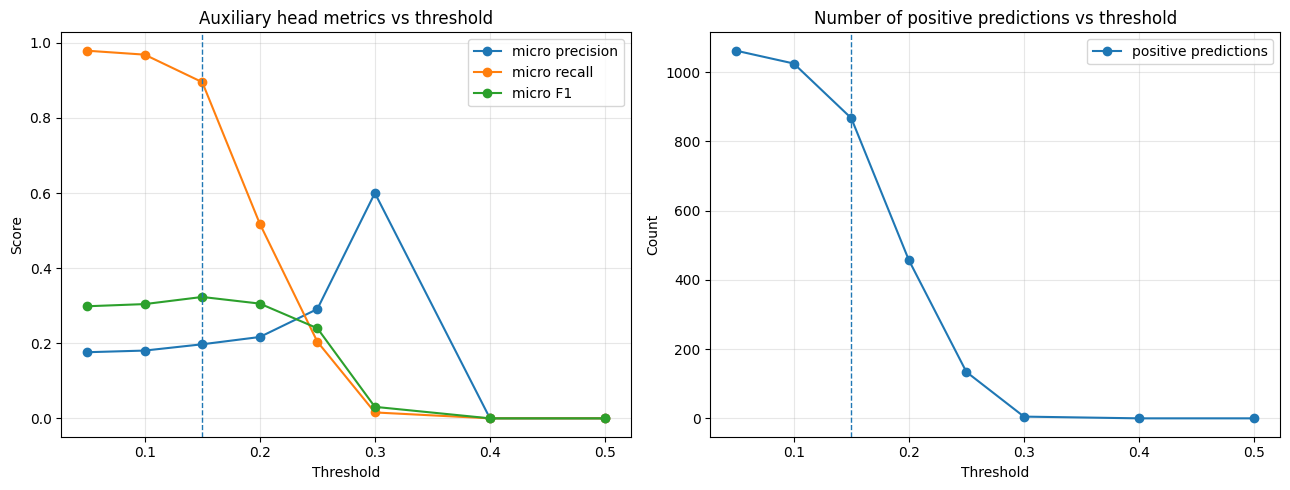

Saved: /content/drive/MyDrive/ProiectD3/outputs/figures/section8_auxiliary_threshold_sweep.png


In [76]:
# Plot threshold sweep pentru head-ul auxiliar

if "auxiliary_threshold_sweep_df" in globals() and len(auxiliary_threshold_sweep_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(
        auxiliary_threshold_sweep_df["threshold"],
        auxiliary_threshold_sweep_df["micro_precision"],
        marker="o",
        label="micro precision"
    )
    axes[0].plot(
        auxiliary_threshold_sweep_df["threshold"],
        auxiliary_threshold_sweep_df["micro_recall"],
        marker="o",
        label="micro recall"
    )
    axes[0].plot(
        auxiliary_threshold_sweep_df["threshold"],
        auxiliary_threshold_sweep_df["micro_f1"],
        marker="o",
        label="micro F1"
    )
    axes[0].axvline(best_aux_threshold, linestyle="--", linewidth=1)
    axes[0].set_title("Auxiliary head metrics vs threshold")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Score")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        auxiliary_threshold_sweep_df["threshold"],
        auxiliary_threshold_sweep_df["positive_predictions"],
        marker="o",
        label="positive predictions"
    )
    axes[1].axvline(best_aux_threshold, linestyle="--", linewidth=1)
    axes[1].set_title("Number of positive predictions vs threshold")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(AUX_THRESHOLD_SWEEP_FIGURE_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", AUX_THRESHOLD_SWEEP_FIGURE_PATH)
else:
    print("No auxiliary threshold sweep data available.")

Evaluarea head-ului auxiliar a fost facuta pe mai multe praguri, deoarece la pragul standard `0.5` modelul nu producea predictii pozitive. Rezultatele arata ca performanta head-ului auxiliar este foarte sensibila la alegerea threshold-ului.

Cel mai bun compromis apare la `threshold = 0.15`, unde se obtine `micro_f1 = 0.3233`, cu `micro_precision = 0.1972` si `micro_recall = 0.8953`. Recall-ul mare arata ca head-ul auxiliar identifica majoritatea claselor prezente in imagini, dar precision-ul mai mic indica faptul ca prezice si multe clase in plus. Acest comportament este vizibil si in graficul cu numarul de predictii pozitive: la praguri mici modelul este foarte permisiv, iar pe masura ce pragul creste, numarul de clase prezise scade rapid.

La praguri mari, precum `0.4` sau `0.5`, modelul nu mai prezice nicio clasa pozitiva, deci precision, recall si F1 devin 0. De aceea, pentru acest head auxiliar, un prag fix de `0.5` nu este potrivit. Head-ul trebuie interpretat ca un modul de semnal global despre clasele posibile din imagine, nu ca un detector separat.

Metricile pe clase confirma acelasi lucru: pentru clase frecvente precum `Plastic film`, `Cigarette` si `Unlabeled litter`, head-ul auxiliar obtine valori rezonabile de F1 la pragul ales. Pentru clase rare, cum este `Broken glass`, performanta ramane slaba, deoarece exista foarte putine exemple pozitive.

### 8.3 Concluzie pe experimente

Tabelul comparativ arata ca fine-tuning-ul imbunatateste clar modelul fata de baseline-ul pretrained adaptat. Modelul simplu fine-tuned obtine predictii mai precise, iar varianta multi-task cu head auxiliar creste recall-ul si F1-ul, detectand mai multe obiecte. Totusi, aceasta crestere vine cu un cost: numarul de false positive este mai mare, iar precision-ul scade.

Prin urmare, head-ul auxiliar ajuta la acoperirea mai buna a obiectelor, dar nu inlocuieste head-urile principale de detectie si segmentare. Rezultatul este util ca experiment multi-task, mai ales pentru a arata compromisul dintre recall si precision.

## 8.4 Rezumat vizual pentru demo

Aceasta sectiune strange intr-un singur loc tabelele si graficele care merita aratate la sustinere. Ordinea este intentionata: intai dimensiunea dataset-ului dupa curatare, apoi comparatia modelelor, apoi loss-urile si metricile standard.

- Tabelul `Dataset after cleaning` explica efectul filtrarii: cate imagini/adnotari raman si cate clase foreground intra efectiv in model.
- Tabelul `Main test metrics` compara modelele la acelasi prag IoU/score, deci diferentele de precision, recall si F1 sunt comparabile direct.
- Graficul cu bare arata vizual compromisul dintre precision si recall: un model poate gasi mai multe obiecte, dar poate produce si mai multe false positive.
- Tabelele COCO AP si auxiliary head completeaza analiza: AP este standardul pentru detectie/segmentare, iar metricele auxiliare arata cat de util este head-ul nou ca semnal global de prezenta a claselor.


,Indicator,Value
0,Raw images,1504.0000
1,Clean images,1123.0000
2,Raw annotations,4819.0000
3,Clean annotations,3185.0000
4,Selected foreground classes,10.0000
5,Image size used by model,512.0000


,model,precision@0.50,recall@0.50,f1@0.50,mean_mask_iou_matched
0,Baseline adapted pretrained,0.0000,0.0000,0.0000,0.0000
1,Fine-tuned Mask R-CNN,0.4245,0.1236,0.1915,0.8296
2,Mask R-CNN + auxiliary head,0.3526,0.1676,0.2272,0.8107


Saved figure: /content/drive/MyDrive/ProiectD3/outputs/figures/section8_demo_metric_bars.png


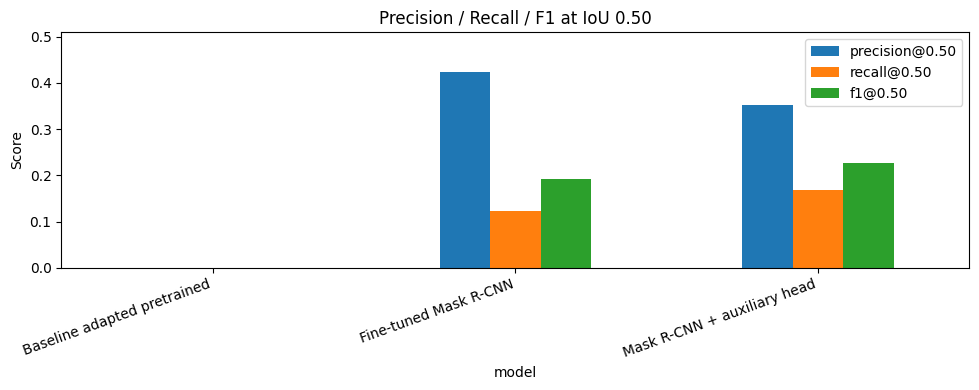

,epochs,final_train_loss,final_valid_loss,best_valid_loss
0,5.0000,0.6336,0.7086,0.7086


,model,type,AP,AP50,AP75,AR_100
0,Fine-tuned Mask R-CNN,bbox,0.1234,0.1924,0.1357,0.2729
1,Fine-tuned Mask R-CNN,segm,0.1142,0.1848,0.1210,0.2606
2,Mask R-CNN + auxiliary head,bbox,0.1210,0.2163,0.1148,0.3016
3,Mask R-CNN + auxiliary head,segm,0.1157,0.1943,0.1275,0.2870


In [77]:
demo_dataset_df = pd.DataFrame([
    {"Indicator": "Raw images", "Value": sum(len(raw_coco[split]["images"]) for split in SPLITS)},
    {"Indicator": "Clean images", "Value": sum(len(clean_coco[split]["images"]) for split in SPLITS)},
    {"Indicator": "Raw annotations", "Value": sum(len(raw_coco[split]["annotations"]) for split in SPLITS)},
    {"Indicator": "Clean annotations", "Value": sum(len(clean_coco[split]["annotations"]) for split in SPLITS)},
    {"Indicator": "Selected foreground classes", "Value": len(clean_categories)},
    {"Indicator": "Image size used by model", "Value": IMAGE_SIZE},
])
show_table(demo_dataset_df, "Dataset after cleaning")

if "experiment_results_df" in globals() and len(experiment_results_df) > 0:
    show_table(experiment_results_df[["model", "precision@0.50", "recall@0.50", "f1@0.50", "mean_mask_iou_matched"]], "Main test metrics")
    metric_plot_df = experiment_results_df.set_index("model")[["precision@0.50", "recall@0.50", "f1@0.50"]]
    ax = metric_plot_df.plot(kind="bar", figsize=(10, 4))
    ax.set_ylim(0, max(0.5, float(metric_plot_df.max().max()) * 1.2))
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall / F1 at IoU 0.50")
    plt.xticks(rotation=20, ha="right")
    save_figure(FIGURES_DIR / "section8_demo_metric_bars.png")
    plt.show()

if "training_history_df" in globals() and len(training_history_df) > 0:
    last_train = training_history_df.iloc[-1]
    training_summary_df = pd.DataFrame([{
        "epochs": int(training_history_df["epoch"].max()),
        "final_train_loss": float(last_train["train_loss"]),
        "final_valid_loss": float(last_train["valid_loss"]),
        "best_valid_loss": float(training_history_df["valid_loss"].min()),
    }])
    show_table(training_summary_df, "Fine-tuning loss summary")

if "coco_metrics_df" in globals() and len(coco_metrics_df) > 0:
    show_table(coco_metrics_df[["model", "type", "AP", "AP50", "AP75", "AR_100"]], "COCO-style metrics")


Graficul compara cele trei variante de model folosind precision, recall si F1 la IoU 0.50. Baseline-ul adaptat pretrained nu produce predictii utile fara fine-tuning. Dupa fine-tuning, modelul Mask R-CNN obtine o imbunatatire clara, mai ales la precision. Varianta cu head auxiliar creste recall-ul si F1-ul, ceea ce arata ca detecteaza mai multe obiecte, dar precision-ul scade deoarece apar mai multe false positive. Astfel, head-ul auxiliar imbunatateste acoperirea obiectelor, dar introduce un compromis intre recall si precision.

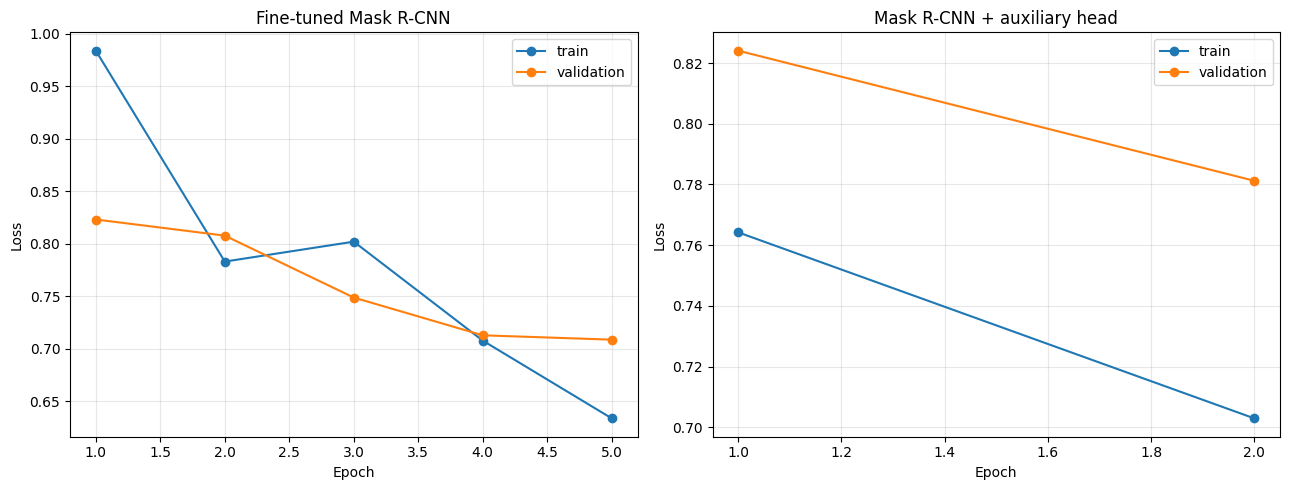

Saved: /content/drive/MyDrive/ProiectD3/outputs/figures/section8_train_valid_loss_curves.png


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if "training_history_df" in globals() and len(training_history_df) > 0:
    axes[0].plot(training_history_df["epoch"], training_history_df["train_loss"], marker="o", label="train")
    axes[0].plot(training_history_df["epoch"], training_history_df["valid_loss"], marker="o", label="validation")
    axes[0].set_title("Fine-tuned Mask R-CNN")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No fine-tuning history", ha="center", va="center")
    axes[0].axis("off")

if "multi_task_history_df" in globals() and len(multi_task_history_df) > 0:
    axes[1].plot(multi_task_history_df["epoch"], multi_task_history_df["train_loss"], marker="o", label="train")
    axes[1].plot(multi_task_history_df["epoch"], multi_task_history_df["valid_loss"], marker="o", label="validation")
    axes[1].set_title("Mask R-CNN + auxiliary head")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No multi-task history", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(EXPERIMENT_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", EXPERIMENT_CURVES_PATH)

### 8.5 Interpretarea tabelelor si graficelor

Tabelul `Dataset after cleaning` justifica fezabilitatea experimentului: dataset-ul ramane suficient de mare dupa filtrarea claselor rare, iar numarul de adnotari curate arata ca modelul primeste in continuare semnal consistent de invatare. Acest tabel nu masoara performanta modelului, ci calitatea si dimensiunea datelor folosite pentru antrenare.

Tabelul `Main test metrics` este comparatia principala intre baseline, modelul fine-tuned si modelul cu head auxiliar. `precision@0.50` raspunde la intrebarea „din predictiile modelului, cate sunt corecte?”, `recall@0.50` raspunde la „din obiectele reale, cate sunt gasite?”, iar `f1@0.50` combina cele doua metrici. `mean_mask_iou_matched` masoara calitatea mastilor doar pentru obiectele deja potrivite, deci trebuie interpretat impreuna cu recall-ul.

Graficul `Precision / Recall / F1 at IoU 0.50` prezinta vizual acelasi tabel. Baseline-ul ramane la valori zero, ceea ce arata ca head-urile adaptate nu sunt suficiente fara fine-tuning. Modelul fine-tuned aduce primul salt real de performanta. Modelul cu head auxiliar creste recall-ul si F1-ul, dar scade precision-ul, ceea ce indica mai multe detectii, dar si mai multe false positive.

Curbele de loss arata stabilitatea antrenarii. Pentru Mask R-CNN simplu, train loss si validation loss scad per total, ceea ce indica faptul ca modelul invata dataset-ul. Pentru modelul multi-task, scaderea simultana a train loss si validation loss arata ca adaugarea head-ului auxiliar nu destabilizeaza antrenarea. Diferenta dintre cele doua grafice nu trebuie interpretata direct ca o comparatie absoluta, deoarece loss-ul multi-task include si componenta auxiliara ponderata.

Tabelul COCO AP este raportarea standard pentru detectie si segmentare. `AP` medieaza performanta peste mai multe praguri IoU, `AP50` este mai permisiv si apropiat de `F1@0.50`, iar `AP75` cere localizare mai stricta. Diferenta dintre randurile `bbox` si `segm` arata separat calitatea cutiilor si calitatea mastilor.

Tabelul head-ului auxiliar nu trebuie citit ca un detector separat. El masoara clasificarea multi-label la nivel de imagine, adica prezice ce clase sunt prezente in imagine. In acest proiect, rolul lui principal este sa ofere un semnal global suplimentar despre clasele posibile, iar detectia si segmentarea raman realizate de head-urile principale ale modelului.

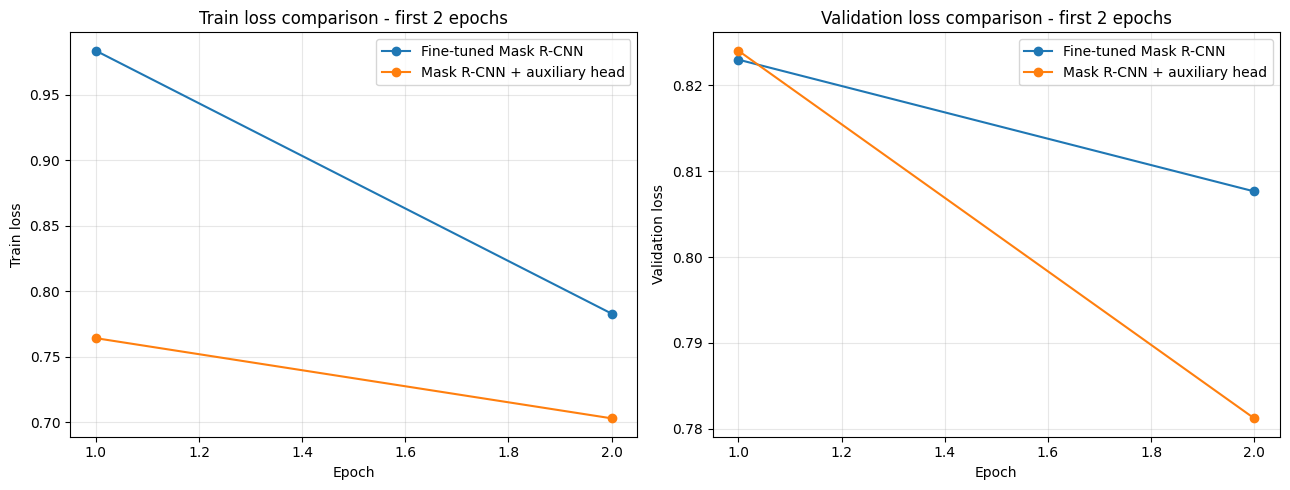

Saved: /content/drive/MyDrive/ProiectD3/outputs/figures/section8_direct_loss_comparison_same_epochs.png


,model,epochs_compared,initial_train_loss,final_train_loss,train_loss_drop,initial_valid_loss,final_valid_loss,valid_loss_drop
0,Fine-tuned Mask R-CNN,2.0000,0.9838,0.7829,0.2008,0.8230,0.8077,0.0154
1,Mask R-CNN + auxiliary head,2.0000,0.7642,0.7030,0.0613,0.8241,0.7812,0.0428


In [79]:
# Comparatie directa intre Fine-tuned Mask R-CNN si Multi-task
# pe acelasi numar de epoci
if (
    "training_history_df" in globals() and len(training_history_df) > 0
    and "multi_task_history_df" in globals() and len(multi_task_history_df) > 0
):
    common_epochs = min(
        int(training_history_df["epoch"].max()),
        int(multi_task_history_df["epoch"].max())
    )

    ft_common = training_history_df[training_history_df["epoch"] <= common_epochs].copy()
    mt_common = multi_task_history_df[multi_task_history_df["epoch"] <= common_epochs].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Train loss comparison
    axes[0].plot(
        ft_common["epoch"],
        ft_common["train_loss"],
        marker="o",
        label="Fine-tuned Mask R-CNN"
    )
    axes[0].plot(
        mt_common["epoch"],
        mt_common["train_loss"],
        marker="o",
        label="Mask R-CNN + auxiliary head"
    )
    axes[0].set_title(f"Train loss comparison - first {common_epochs} epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # ------------------------------
    # Validation loss comparison
    # ------------------------------
    axes[1].plot(
        ft_common["epoch"],
        ft_common["valid_loss"],
        marker="o",
        label="Fine-tuned Mask R-CNN"
    )
    axes[1].plot(
        mt_common["epoch"],
        mt_common["valid_loss"],
        marker="o",
        label="Mask R-CNN + auxiliary head"
    )
    axes[1].set_title(f"Validation loss comparison - first {common_epochs} epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()

    LOSS_COMPARISON_PATH = FIGURES_DIR / "section8_direct_loss_comparison_same_epochs.png"
    plt.savefig(LOSS_COMPARISON_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", LOSS_COMPARISON_PATH)

    # Numeric summary
    comparison_rows = []

    comparison_rows.append({
        "model": "Fine-tuned Mask R-CNN",
        "epochs_compared": common_epochs,
        "initial_train_loss": ft_common["train_loss"].iloc[0],
        "final_train_loss": ft_common["train_loss"].iloc[-1],
        "train_loss_drop": ft_common["train_loss"].iloc[0] - ft_common["train_loss"].iloc[-1],
        "initial_valid_loss": ft_common["valid_loss"].iloc[0],
        "final_valid_loss": ft_common["valid_loss"].iloc[-1],
        "valid_loss_drop": ft_common["valid_loss"].iloc[0] - ft_common["valid_loss"].iloc[-1],
    })

    comparison_rows.append({
        "model": "Mask R-CNN + auxiliary head",
        "epochs_compared": common_epochs,
        "initial_train_loss": mt_common["train_loss"].iloc[0],
        "final_train_loss": mt_common["train_loss"].iloc[-1],
        "train_loss_drop": mt_common["train_loss"].iloc[0] - mt_common["train_loss"].iloc[-1],
        "initial_valid_loss": mt_common["valid_loss"].iloc[0],
        "final_valid_loss": mt_common["valid_loss"].iloc[-1],
        "valid_loss_drop": mt_common["valid_loss"].iloc[0] - mt_common["valid_loss"].iloc[-1],
    })

    loss_comparison_df = pd.DataFrame(comparison_rows)
    show_table(loss_comparison_df, "Direct loss comparison on same number of epochs")

else:
    print("Training history or multi-task history is not available.")

Graficul compara cele doua modele pe acelasi numar de epoci, pentru o comparatie corecta. Ambele variante au loss-uri in scadere, deci antrenarea este stabila. Mask R-CNN simplu reduce mai mult train loss-ul, in timp ce modelul cu head auxiliar reduce mai mult validation loss-ul. Acest lucru sugereaza ca head-ul auxiliar poate ajuta la generalizare in primele epoci. Totusi, valorile absolute ale loss-ului nu trebuie comparate direct, deoarece modelul multi-task include si o componenta auxiliara in loss-ul total.

## 8.6 Vizualizari rezultate pe test

Urmatoarele celule selecteaza automat mai multe exemple reusite si un numar mai mic de exemple slabe pe setul de test. Fiecare figura compara ground truth cu predictiile modelului si afiseaza F1-ul imaginii, IoU-ul mediu al mastilor potrivite, numarul de predictii si numarul de obiecte reale.

Pentru demo, exemplele reusite sunt mai numeroase deoarece arata concret ce a invatat modelul. Exemplele de esec raman incluse pentru analiza critica: imagini aglomerate, obiecte mici, clase rare sau predictii sub pragul de scor.

Figurile sunt salvate in `outputs/figures`, astfel incat pot fi incluse direct in raportul LaTeX sau arhiva finala.


## 8.6.1 Postprocesare predictii

Modelul `torchvision` Mask R-CNN aplica intern postprocesarea specifica detectiei, inclusiv NMS pentru bounding boxes. In celulele de vizualizare mai aplicam doua praguri explicite:

- `SCORE_THRESHOLD = 0.5`, pentru a pastra doar predictiile suficient de sigure;
- `MASK_THRESHOLD = 0.5`, pentru a transforma probabilitatile mastii in masca binara.

In [80]:
class_id_to_name = {cat["id"]: cat["name"] for cat in clean_categories}

NUM_SUCCESS_VISUALIZATIONS = 6
NUM_FAILURE_VISUALIZATIONS = 2
MAX_INSTANCES_PER_PANEL = 12


def tensor_image_to_numpy(image_tensor):
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(image, 0.0, 1.0)


def get_class_name(label):
    return class_id_to_name.get(int(label), f"class_{int(label)}")


def draw_instances(ax, image_np, boxes, labels, masks=None, scores=None, title="", score_threshold=0.0, max_instances=10):
    ax.imshow(image_np)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if boxes is None or len(boxes) == 0:
        ax.text(0.02, 0.98, "No instances", transform=ax.transAxes, va="top", bbox=dict(facecolor="white", alpha=0.8))
        return
    color_map = plt.cm.get_cmap("tab20", 20)
    drawn = 0
    for idx in range(len(boxes)):
        if scores is not None and float(scores[idx]) < score_threshold:
            continue
        if drawn >= max_instances:
            break
        label = int(labels[idx])
        color = color_map(label % 20)
        x1, y1, x2, y2 = [float(value) for value in boxes[idx]]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.8, edgecolor=color, facecolor="none"))
        text = get_class_name(label) + (f" {float(scores[idx]):.2f}" if scores is not None else "")
        ax.text(x1, max(0, y1 - 3), text, fontsize=7, color="black", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
        if masks is not None and len(masks) > idx:
            mask = masks[idx].detach().cpu().numpy() if torch.is_tensor(masks[idx]) else masks[idx]
            rgba = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.float32)
            rgba[..., :3] = color[:3]
            rgba[..., 3] = mask.astype(bool).astype(np.float32) * 0.32
            ax.imshow(rgba)
        drawn += 1
    if drawn == 0:
        ax.text(0.02, 0.98, "No predictions over threshold", transform=ax.transAxes, va="top", bbox=dict(facecolor="white", alpha=0.8))


def select_visualization_indices(per_image_df, num_good=6, num_failure=2):
    if per_image_df is None or len(per_image_df) == 0:
        return list(range(min(num_good + num_failure, len(test_dataset))))

    good_df = (
        per_image_df[per_image_df["tp"] > 0]
        .sort_values(["f1", "mean_mask_iou_matched", "recall", "precision"], ascending=False)
        .head(num_good)
    )
    failure_df = (
        per_image_df
        .sort_values(["f1", "num_gt", "fn", "fp"], ascending=[True, False, False, False])
        .head(num_failure)
    )

    indices = []
    for value in list(good_df["dataset_index"]) + list(failure_df["dataset_index"]):
        value = int(value)
        if value not in indices:
            indices.append(value)

    filler = 0
    target_count = min(num_good + num_failure, len(test_dataset))
    while len(indices) < target_count:
        if filler not in indices:
            indices.append(filler)
        filler += 1
    return indices[:target_count]


@torch.no_grad()
def visualize_predictions_for_indices(model, dataset, indices, model_name, save_prefix, score_threshold=0.5):
    model.eval()
    saved_paths = []
    for rank, dataset_index in enumerate(indices, start=1):
        image_tensor, target = dataset[dataset_index]
        image_np = tensor_image_to_numpy(image_tensor)
        output = unpack_detections(model([image_tensor.to(device)]))[0]
        output = {key: value.detach().cpu() for key, value in output.items()}
        scores = output.get("scores", torch.empty((0,)))
        keep = scores >= score_threshold
        pred_boxes = output.get("boxes", torch.empty((0, 4)))[keep]
        pred_labels = output.get("labels", torch.empty((0,), dtype=torch.int64))[keep]
        pred_scores = scores[keep]
        pred_masks = output["masks"][keep, 0] >= MASK_THRESHOLD if "masks" in output else None
        metrics = compute_single_image_metrics(output, target, score_threshold, MASK_THRESHOLD, IOU_THRESHOLD)
        image_id = int(target["image_id"].flatten()[0])
        status = "success" if metrics["f1"] > 0 else "failure"

        fig, axes = plt.subplots(1, 2, figsize=(11, 5))
        draw_instances(
            axes[0], image_np, target["boxes"], target["labels"], masks=target["masks"].bool(),
            title=f"Ground truth | image_id={image_id}", max_instances=MAX_INSTANCES_PER_PANEL,
        )
        pred_title = f"{model_name} | {status}\nF1={metrics['f1']:.2f}, mask IoU={metrics['mean_mask_iou_matched']:.2f}, pred={metrics['num_predictions']}, gt={metrics['num_gt']}"
        draw_instances(
            axes[1], image_np, pred_boxes, pred_labels, masks=pred_masks, scores=pred_scores,
            title=pred_title, max_instances=MAX_INSTANCES_PER_PANEL,
        )
        save_path = FIGURES_DIR / f"{save_prefix}_{rank:02d}_{status}_image_{image_id}.png"
        save_figure(save_path)
        plt.show()
        saved_paths.append(save_path)
    return saved_paths


visualization_model_name = "Mask R-CNN + auxiliary head" if BEST_MULTI_TASK_MODEL_PATH.exists() else "Fine-tuned Mask R-CNN"
visualization_model = build_multi_task_model_for_eval() if BEST_MULTI_TASK_MODEL_PATH.exists() else build_finetuned_model_for_eval()
selected_per_image_df = per_image_results.get(visualization_model_name)
if selected_per_image_df is None or len(selected_per_image_df) == 0:
    _, selected_per_image_df = evaluate_instance_segmentation_model(visualization_model, test_loader, device, visualization_model_name, EVAL_MAX_BATCHES, SCORE_THRESHOLD)

selected_indices = select_visualization_indices(
    selected_per_image_df,
    num_good=NUM_SUCCESS_VISUALIZATIONS,
    num_failure=NUM_FAILURE_VISUALIZATIONS,
)
print("Selected test indices:", selected_indices)
prediction_figure_paths = visualize_predictions_for_indices(visualization_model, test_dataset, selected_indices, visualization_model_name, "section8_predictions", SCORE_THRESHOLD)
print("Saved prediction figures:")
for path_item in prediction_figure_paths:
    print(path_item)

del visualization_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Output hidden; open in https://colab.research.google.com to view.

Exemplele de esec arata cazuri dificile pentru model: obiectele sunt foarte mici, numeroase si apar pe fundaluri aglomerate sau cu textura similara. In aceste imagini, modelul nu produce predictii peste pragul de scor folosit, deci rezultatul este `pred=0`, `F1=0` si `mask IoU=0`. Aceste cazuri explica de ce recall-ul ramane limitat: modelul rateaza mai ales obiectele mici, greu vizibile sau foarte apropiate de fundal.

Exemplele de succes arata situatii in care obiectul este clar vizibil, bine delimitat si apare pe un fundal mai simplu. Modelul detecteaza corect instanta, iar masca prezisa se suprapune bine peste adnotarea reala, obtinand `F1=1.00` si un `mask IoU` ridicat. Aceste cazuri confirma ca modelul a invatat clasele principale atunci cand obiectele sunt suficient de vizibile si nu sunt confundate cu fundalul.

In [81]:
success_examples_df = (
    selected_per_image_df[selected_per_image_df["tp"] > 0]
    .sort_values(["f1", "mean_mask_iou_matched", "recall", "precision"], ascending=False)
    .head(NUM_SUCCESS_VISUALIZATIONS)
    [["model", "dataset_index", "image_id", "num_gt", "num_predictions", "tp", "fp", "fn", "precision", "recall", "f1", "mean_mask_iou_matched"]]
)

failure_examples_df = (
    selected_per_image_df
    .sort_values(["f1", "num_gt", "fn", "fp"], ascending=[True, False, False, False])
    .head(max(5, NUM_FAILURE_VISUALIZATIONS))
    [["model", "dataset_index", "image_id", "num_gt", "num_predictions", "tp", "fp", "fn", "precision", "recall", "f1", "mean_mask_iou_matched"]]
)

print("Cele mai bune exemple de test, utile pentru demo-ul vizual:")
display(success_examples_df)
print("Cele mai slabe exemple de test, utile pentru discutia de erori:")
display(failure_examples_df)


Cele mai bune exemple de test, utile pentru demo-ul vizual:


,model,dataset_index,image_id,num_gt,num_predictions,tp,fp,fn,precision,recall,f1,mean_mask_iou_matched
98,Mask R-CNN + auxiliary head,98,129,1,1,1,0,0,1.0,1.0,1.0,0.960249
18,Mask R-CNN + auxiliary head,18,26,1,1,1,0,0,1.0,1.0,1.0,0.956997
1,Mask R-CNN + auxiliary head,1,2,1,1,1,0,0,1.0,1.0,1.0,0.955577
40,Mask R-CNN + auxiliary head,40,52,1,1,1,0,0,1.0,1.0,1.0,0.931656
41,Mask R-CNN + auxiliary head,41,53,1,1,1,0,0,1.0,1.0,1.0,0.930445
90,Mask R-CNN + auxiliary head,90,121,1,1,1,0,0,1.0,1.0,1.0,0.889684


Cele mai slabe exemple de test, utile pentru discutia de erori:


,model,dataset_index,image_id,num_gt,num_predictions,tp,fp,fn,precision,recall,f1,mean_mask_iou_matched
19,Mask R-CNN + auxiliary head,19,27,28,0,0,0,28,0.0,0.0,0.0,0.0
9,Mask R-CNN + auxiliary head,9,13,17,0,0,0,17,0.0,0.0,0.0,0.0
31,Mask R-CNN + auxiliary head,31,43,12,1,0,1,12,0.0,0.0,0.0,0.0
61,Mask R-CNN + auxiliary head,61,85,9,2,0,2,9,0.0,0.0,0.0,0.0
14,Mask R-CNN + auxiliary head,14,22,7,2,0,2,7,0.0,0.0,0.0,0.0


In [82]:
# Afisare top cele mai bune si top cele mai slabe exemple

TOP_BEST_VISUALIZATIONS = 6
TOP_WORST_VISUALIZATIONS = 5

visualization_model_name = "Mask R-CNN + auxiliary head" if BEST_MULTI_TASK_MODEL_PATH.exists() else "Fine-tuned Mask R-CNN"
visualization_model = build_multi_task_model_for_eval() if BEST_MULTI_TASK_MODEL_PATH.exists() else build_finetuned_model_for_eval()

selected_per_image_df = per_image_results.get(visualization_model_name)

if selected_per_image_df is None or len(selected_per_image_df) == 0:
    _, selected_per_image_df = evaluate_instance_segmentation_model(
        visualization_model,
        test_loader,
        device,
        visualization_model_name,
        EVAL_MAX_BATCHES,
        SCORE_THRESHOLD
    )

best_examples_df = (
    selected_per_image_df[selected_per_image_df["tp"] > 0]
    .sort_values(
        ["f1", "mean_mask_iou_matched", "recall", "precision"],
        ascending=False
    )
    .head(TOP_BEST_VISUALIZATIONS)
)

worst_examples_df = (
    selected_per_image_df
    .sort_values(
        ["f1", "num_gt", "fn", "fp"],
        ascending=[True, False, False, False]
    )
    .head(TOP_WORST_VISUALIZATIONS)
)

best_indices = best_examples_df["dataset_index"].astype(int).tolist()
worst_indices = worst_examples_df["dataset_index"].astype(int).tolist()

print("Top best indices:", best_indices)
display(best_examples_df)

best_prediction_paths = visualize_predictions_for_indices(
    visualization_model,
    test_dataset,
    best_indices,
    visualization_model_name,
    "section8_top_best_predictions",
    SCORE_THRESHOLD
)

print("Top worst indices:", worst_indices)
display(worst_examples_df)

worst_prediction_paths = visualize_predictions_for_indices(
    visualization_model,
    test_dataset,
    worst_indices,
    visualization_model_name,
    "section8_top_worst_predictions",
    SCORE_THRESHOLD
)

print("Saved best prediction figures:")
for path_item in best_prediction_paths:
    print(path_item)

print("Saved worst prediction figures:")
for path_item in worst_prediction_paths:
    print(path_item)

del visualization_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Output hidden; open in https://colab.research.google.com to view.

## 8.7 Concluzii evaluare

Curbele de loss si tabelele de test sustin aceeasi concluzie: modelul invata dupa fine-tuning, iar head-ul auxiliar schimba comportamentul prin cresterea recall-ului. Exemplele de succes arata ca modelul poate localiza si segmenta corect obiecte din clasele pastrate, in timp ce exemplele de esec sunt utile pentru demo deoarece arata limitarile reale: imagini aglomerate, obiecte mici, clase rare sau predictii sub pragul de scor.

Pentru raportare finala, includem atat F1@0.50, cat si COCO AP, deoarece F1-ul este intuitiv, iar AP este metrica standard pentru detectie si segmentare. Head-ul auxiliar este prezentat corect ca mecanism multi-task/regularizare: performanta lui proprie la prag fix nu este obiectivul principal, dar efectul asupra detectorului se vede in comparatia de F1 si recall.


# 9. Bonus optional

Am implementat doua componente bonus care nu necesita antrenare de la zero:

1. **Discutie bias in date si model**: analiza dezechilibrului dintre clase si propuneri de mitigare.
2. **Demo Gradio optional**: codul este pregatit, dar lansarea este dezactivata implicit ca sa nu porneasca servere in timpul rularii normale a notebook-ului.

In [83]:
# Bonus +2p: bias in date si model.
bias_analysis_df = clean_class_distribution_df.copy()
bias_analysis_df["percentage"] = 100 * bias_analysis_df["total_count"] / bias_analysis_df["total_count"].sum()
bias_analysis_df["relative_to_max"] = bias_analysis_df["total_count"] / bias_analysis_df["total_count"].max()
imbalance_ratio = bias_analysis_df["total_count"].max() / max(1, bias_analysis_df["total_count"].min())
underrepresented_classes = bias_analysis_df[bias_analysis_df["total_count"] <= bias_analysis_df["total_count"].median()]["class_name"].tolist()

print("Class imbalance ratio max/min:", round(imbalance_ratio, 2))
print("Underrepresented selected classes:", underrepresented_classes)
display(bias_analysis_df)

bias_mitigation_notes = {
    "observed_bias": "Clasele frecvente pot domina loss-ul si pot avea performanta mai buna decat clasele rare.",
    "possible_effect": "Modelul poate rata obiecte mici, partial acoperite sau din clase sub-reprezentate.",
    "mitigations": [
        "class-aware sampling",
        "augmentari tintite pentru clase rare",
        "raportare metrici per clasa",
        "colectare suplimentara de imagini pentru clasele slabe",
    ],
}
bias_mitigation_notes

Class imbalance ratio max/min: 4.83
Underrepresented selected classes: ['Other plastic wrapper', 'Drink can', 'Plastic bottle cap', 'Plastic straw', 'Broken glass']


,new_category_id,class_name,train_count,valid_count,test_count,total_count,percentage,relative_to_max
0,1,Cigarette,430,148,89,667,20.941915,1.000000
1,2,Unlabeled litter,374,93,50,517,16.232339,0.775112
2,3,Plastic film,310,81,60,451,14.160126,0.676162
3,4,Clear plastic bottle,217,50,18,285,8.948195,0.427286
4,5,Other plastic,201,39,33,273,8.571429,0.409295
5,6,Other plastic wrapper,196,34,29,259,8.131868,0.388306
6,7,Drink can,167,33,29,229,7.189953,0.343328
7,8,Plastic bottle cap,150,44,15,209,6.562009,0.313343
8,9,Plastic straw,121,24,12,157,4.929356,0.235382
9,10,Broken glass,92,15,31,138,4.332810,0.206897


{'observed_bias': 'Clasele frecvente pot domina loss-ul si pot avea performanta mai buna decat clasele rare.',
 'possible_effect': 'Modelul poate rata obiecte mici, partial acoperite sau din clase sub-reprezentate.',
 'mitigations': ['class-aware sampling',
  'augmentari tintite pentru clase rare',
  'raportare metrici per clasa',
  'colectare suplimentara de imagini pentru clasele slabe']}

## Bonus: bias in date si model

Dataset-ul ramane dezechilibrat chiar dupa filtrarea claselor rare. Clasele cu multe instante influenteaza mai mult gradientul, iar modelul poate obtine rezultate bune pe clase frecvente si rezultate slabe pe clase sub-reprezentate.

Mitigari posibile:
- sampling orientat pe clase rare;
- augmentari mai multe pentru clase sub-reprezentate;
- raportare de metrici per clasa, nu doar medie globala;
- colectare suplimentara de imagini pentru clasele slabe.

In [84]:
# Bonus +1p: demo interactiv optional cu Gradio.
# Seteaza RUN_GRADIO_DEMO=True
RUN_GRADIO_DEMO = True

if RUN_GRADIO_DEMO:
    if importlib.util.find_spec("gradio") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    gr = importlib.import_module("gradio")

    if BEST_MULTI_TASK_MODEL_PATH.exists():
        demo_model = build_multi_task_model_for_eval()
        demo_model_name = "Mask R-CNN + auxiliary head"
    elif BEST_MODEL_PATH.exists():
        demo_model = build_finetuned_model_for_eval()
        demo_model_name = "Fine-tuned Mask R-CNN"
    else:
        raise FileNotFoundError("No trained checkpoint found for the demo.")

    @torch.no_grad()
    def predict_with_demo(input_image):
        image = np.array(input_image.convert("RGB"))
        transformed = eval_transforms(image=image, bboxes=[], masks=[], class_labels=[])
        image_tensor = torch.as_tensor(transformed["image"], dtype=torch.float32).permute(2, 0, 1) / 255.0
        output = unpack_detections(demo_model([image_tensor.to(device)]))[0]
        output = {key: value.detach().cpu() for key, value in output.items()}
        image_np = tensor_image_to_numpy(image_tensor)

        scores = output.get("scores", torch.empty((0,)))
        keep = scores >= SCORE_THRESHOLD
        boxes = output.get("boxes", torch.empty((0, 4)))[keep]
        labels = output.get("labels", torch.empty((0,), dtype=torch.int64))[keep]
        scores = scores[keep]
        masks = output["masks"][keep, 0] >= MASK_THRESHOLD if "masks" in output else None

        fig, ax = plt.subplots(figsize=(7, 7))
        draw_instances(ax, image_np, boxes, labels, masks=masks, scores=scores, title=demo_model_name)
        fig.canvas.draw()
        result = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        plt.close(fig)
        return result

    demo = gr.Interface(fn=predict_with_demo, inputs=gr.Image(type="pil"), outputs=gr.Image(type="numpy"), title="TACO Trash Instance Segmentation")
    demo.launch(share=True)
else:
    print("Gradio demo is implemented but not launched. Set RUN_GRADIO_DEMO=True to start it in Colab.")

Loaded multi-task checkpoint: /content/drive/MyDrive/ProiectD3/outputs/models/maskrcnn_resnet50_fpn_aux_head_best.pth
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://113b8fc605d8ee96c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [85]:
# Actualizam requirements.txt dupa instalarile facute pe parcursul notebook-ului.
!pip freeze > "{REQUIREMENTS_PATH}"
print(f"requirements.txt updated at: {REQUIREMENTS_PATH}")

requirements.txt updated at: /content/drive/MyDrive/ProiectD3/requirements.txt
